# Notebook 05 — Phân tích kinh doanh (Descriptive)

**Mục tiêu:** Phân tích tình hình kinh doanh tổng thể

- Revenue, COGS, Gross Profit Margin theo thời gian
- Xác định các vấn đề cốt lõi trong hoạt động kinh doanh
- Phân tích nguyên nhân tiềm ẩn

In [ ]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import datetime

from src.data_loader import load_processed
from pathlib import Path
from src.plot_utils import save_business

sns.set_theme(style='whitegrid')
%matplotlib inline

In [2]:
sales      = load_processed('sales_clean.csv')
orders     = load_processed('orders_clean.csv')
order_items = load_processed('order_items_clean.csv')
products   = load_processed('products_clean.csv')
returns    = load_processed('returns_clean.csv')
web_traffic = load_processed('web_traffic_clean.csv')
payments   = load_processed('payments_clean.csv')
promotions = load_processed('promotions_clean.csv')
inventory = load_processed('inventory_clean.csv')
geography = load_processed('geography_clean.csv')
customers  = load_processed('customers_clean.csv')
reviews   = load_processed('reviews_clean.csv')
shipments = load_processed('shipments_clean.csv')


d:\Code\DS_Code\revenue_forecast_ecommerce\notebooks\..\src\data_loader.py:40: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(PROCESSED / subfolder / filename)


## 1. Tổng quan tình hình kinh doanh 

**KPIs cần tính**:
- Total Revenue
- Total Orders
- Average Order Value (AOV)
- Gross Profit Margin (%)

### 1.1. Xu hướng Doanh Thu và Biên lợi nhuận theo thời gian

,Year,Total_Revenue,Total_COGS,Profit_Margin
0,2012,7.414977e+08,5.874619e+08,0.207736
1,2013,1.657169e+09,1.465980e+09,0.115371
2,2014,1.871846e+09,1.574607e+09,0.158794
3,2015,1.889934e+09,1.665442e+09,0.118783
4,2016,2.104641e+09,1.780559e+09,0.153984


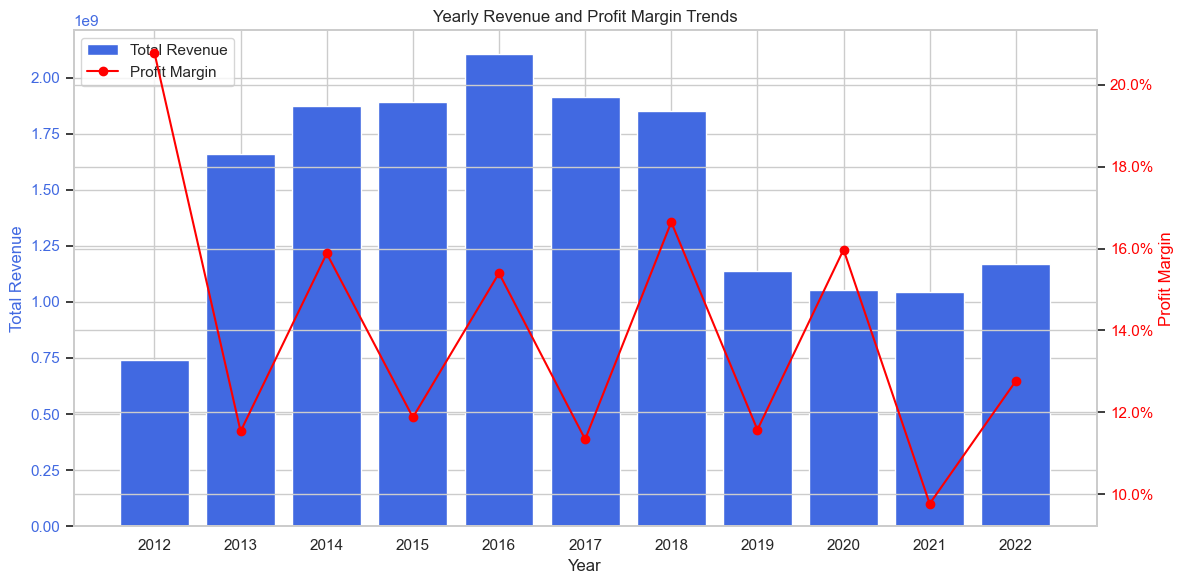

In [ ]:
# 1) Yearly revenue and profit margin trends
# Parse date column and extract year
sales['date'] = pd.to_datetime(sales['date'], errors='coerce')
sales['Year'] = sales['date'].dt.year

# Calculate yearly revenue and COGS
yearly_sales = sales.groupby('Year').agg(
    Total_Revenue=('revenue', 'sum'),
    Total_COGS=('cogs', 'sum')
).reset_index()

# Calculate profit margin
yearly_sales['Profit_Margin'] = (yearly_sales['Total_Revenue'] - yearly_sales['Total_COGS']) / yearly_sales['Total_Revenue']

display(yearly_sales.head())

yearly_sales = yearly_sales.sort_values('Year')
x = range(len(yearly_sales))

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(x, yearly_sales['Total_Revenue'], color='royalblue', label='Total Revenue')
ax1.set_ylabel('Total Revenue', color='royalblue')
ax1.tick_params(axis='y', labelcolor='royalblue')
ax1.set_xticks(x)
ax1.set_xticklabels(yearly_sales['Year'])

ax2 = ax1.twinx()
ax2.plot(x, yearly_sales['Profit_Margin'], color='red', marker='o', label='Profit Margin')
ax2.set_ylabel('Profit Margin', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(1))

ax1.set_xlabel('Year')
ax1.set_title('Yearly Revenue and Profit Margin Trends')

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper left')

plt.tight_layout()
save_business('yearly_revenue_profit_margin')
plt.show()

- Giai đoạn đầu (2012 - 2018) doanh thu tăng rất nhanh, nhưng sau khi đạt đỉnh thì rơi vào trạng thái suy giảm (từ 2019) và chưa phục hồi về nền cũ.
- **Biên lợi nhuận không phát triển tương ứng với doanh thu**: Có năm doanh thu cao nhưng biên lợi nhuận không thật sự vượt trội, ngược lại có năm doanh thu thấp nhưng margin rất tốt. 
- Các cú lên xuống của margin khá gắt.

=> **Biện lợi nhuận biến động qua các năm, đặc biệt có xu hướng giảm mạnh vào các năm lẻ.**

### 1.2. Xu hướng doanh thu theo thời gian

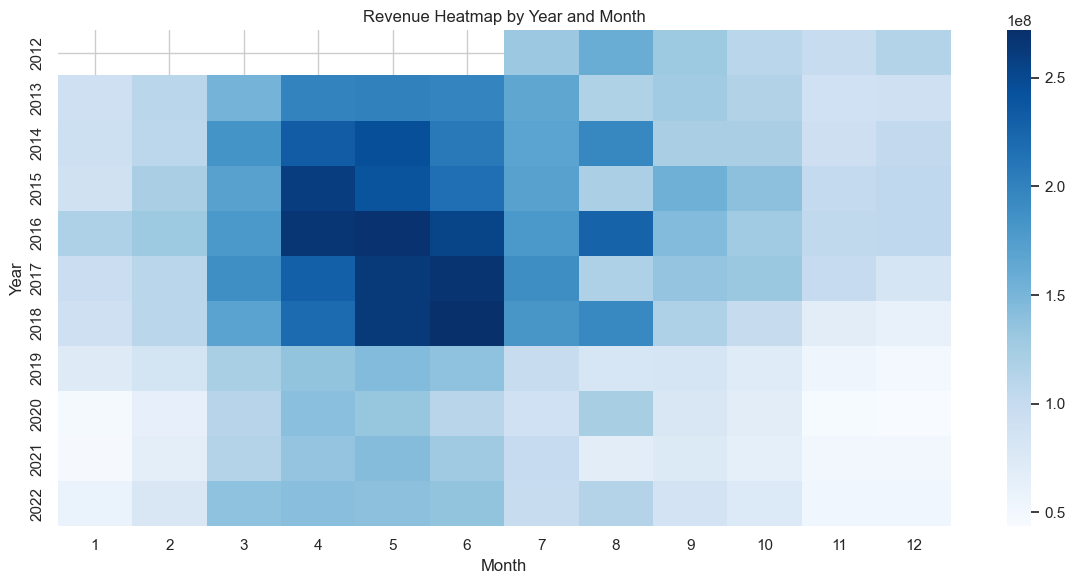

In [ ]:
# 2) Revenue seasonality heatmap
# Parse date column and extract year/month
sales['date'] = pd.to_datetime(sales['date'], errors='coerce')
sales['Year'] = sales['date'].dt.year
sales['Month_Num'] = sales['date'].dt.month

seasonality = sales.groupby(['Year', 'Month_Num'], as_index=False)['revenue'].sum()
heatmap_data = seasonality.pivot(index='Year', columns='Month_Num', values='revenue')

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap='Blues', annot=False, fmt='.0f')
plt.title('Revenue Heatmap by Year and Month')
plt.xlabel('Month')
plt.ylabel('Year')
plt.tight_layout()
save_business('revenue_heatmap')
plt.show()

Doanh thu có **mùa vụ khá rõ**. Các **tháng 4–6** thường là giai đoạn doanh thu cao nhất, đặc biệt **giai đoạn 2014–2018**. Trong đó 2016–2018 là cụm năm mạnh nhất, màu đậm tập trung nhiều ở tháng 4, 5, 6.

### 1.3. Doanh thu và Web traffic

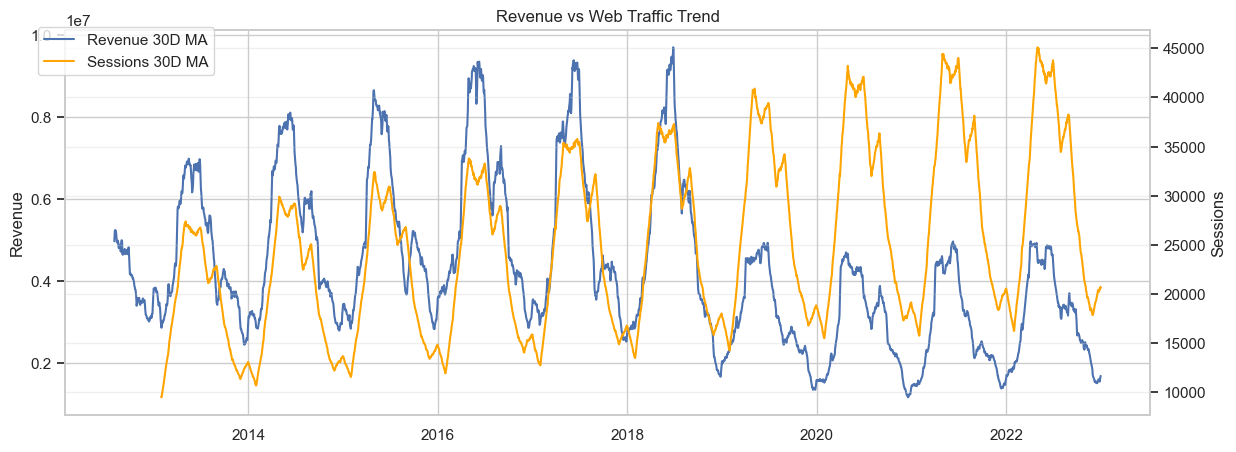

In [ ]:
# 3) Revenue vs Web Traffic Trend
sales['date'] = pd.to_datetime(sales['date'], errors='coerce')
daily_sales = sales.groupby('date', as_index=False)['revenue'].sum()
daily_sales = daily_sales.sort_values('date')
daily_sales['revenue_30D_MA'] = daily_sales['revenue'].rolling(30).mean()
daily_sales['revenue_90D_MA'] = daily_sales['revenue'].rolling(90).mean()
web_traffic['date'] = pd.to_datetime(web_traffic['date'])

traffic_daily = web_traffic.groupby('date', as_index=False).agg(
    sessions=('sessions', 'sum'),
    visitors=('unique_visitors', 'sum')
)

rev_traffic = daily_sales.merge(
    traffic_daily,
    left_on='date',
    right_on='date',
    how='left'
)

fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.plot(rev_traffic['date'], rev_traffic['revenue_30D_MA'], label='Revenue 30D MA')
ax1.set_ylabel('Revenue')

ax2 = ax1.twinx()
ax2.plot(rev_traffic['date'], rev_traffic['sessions'].rolling(30).mean(), label='Sessions 30D MA', color='orange')
ax2.set_ylabel('Sessions')

plt.title('Revenue vs Web Traffic Trend')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.grid(alpha=0.3)
save_business('revenue_vs_web_traffic_trend')
plt.show()

- Giai đoạn 2013–2018, Revenue 30D MA và Sessions 30D MA đi khá cùng chiều. Mỗi khi traffic tăng theo mùa, doanh thu cũng tăng theo. Điều này cho thấy lúc đó doanh nghiệp còn **chuyển đổi traffic thành doanh thu khá tốt**.
- Nhưng từ khoảng 2019 trở đi, hai đường bắt đầu tách pha rõ rệt: Sessions vẫn tăng mạnh, thậm chí đạt mức cao nhất vào 2020–2022, nhưng Revenue lại giảm và không phục hồi tương ứng. 

**=> Marketing tốt, thu hút KH ổn định, nhưng chưa chuyển hóa được thành doanh thu.**

### 1.4. Order và AOV

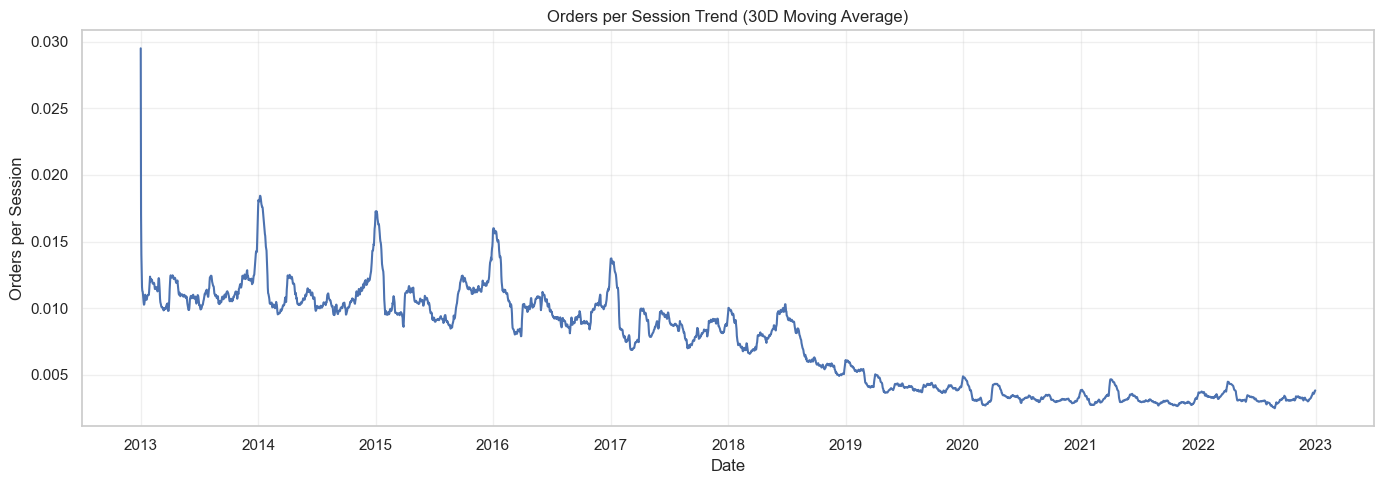

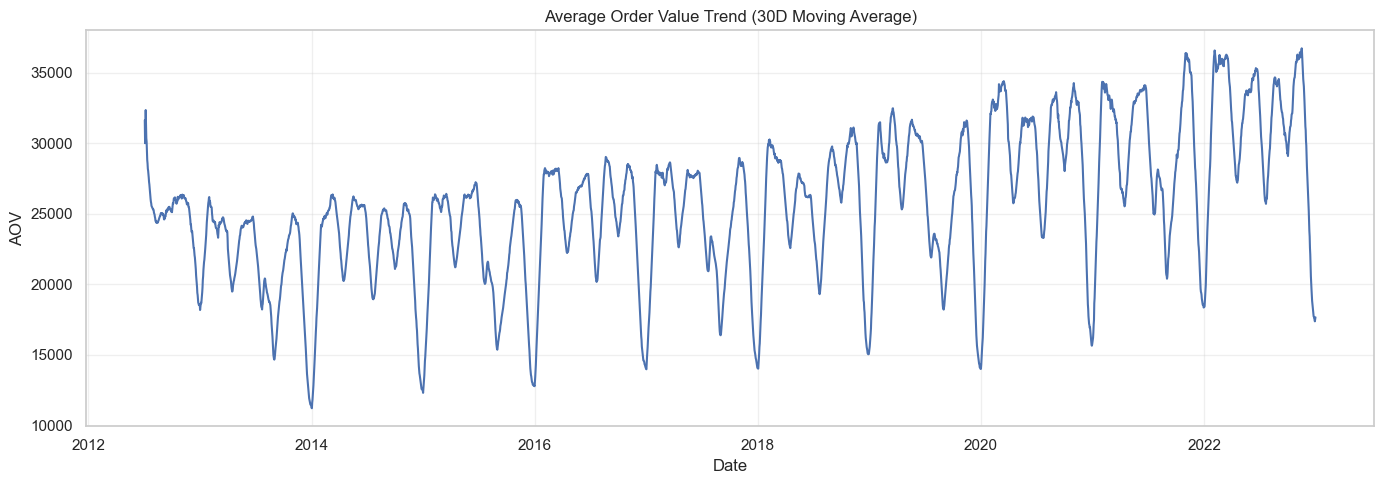

In [ ]:
# 4) Conversion funnel analysis
orders['order_date'] = pd.to_datetime(orders['order_date'], errors='coerce')
web_traffic['date'] = pd.to_datetime(web_traffic['date'], errors='coerce')

traffic_daily = web_traffic.groupby('date', as_index=False).agg(
    sessions=('sessions', 'sum'),
    visitors=('unique_visitors', 'sum')
)

daily_orders = orders.groupby('order_date', as_index=False).agg(
    Orders=('order_id', 'nunique')
)

funnel = rev_traffic.merge(
    daily_orders,
    left_on='date',
    right_on='order_date',
    how='left'
)

funnel['Orders'] = funnel['Orders'].fillna(0)
funnel['Orders_per_Session'] = np.where(
    funnel['sessions'] > 0,
    funnel['Orders'] / funnel['sessions'],
    np.nan
)
funnel['OPS_30D_MA'] = funnel['Orders_per_Session'].rolling(30, min_periods=1).mean()
funnel['Year'] = funnel['date'].dt.year

plt.figure(figsize=(14, 5))
plt.plot(funnel['date'], funnel['OPS_30D_MA'])
plt.title('Orders per Session Trend (30D Moving Average)')
plt.xlabel('Date')
plt.ylabel('Orders per Session')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

yearly_funnel = funnel.groupby('Year', as_index=False)['Orders_per_Session'].mean()

payments_orders = payments.merge(
    orders[['order_id', 'order_date', 'order_status']],
    on='order_id',
    how='left'
)

daily_aov = payments_orders.groupby('order_date', as_index=False).agg(
    Orders=('order_id', 'nunique'),
    Payment_Value=('payment_value', 'sum')
)

daily_aov['AOV'] = daily_aov['Payment_Value'] / daily_aov['Orders']
daily_aov['AOV_30D_MA'] = daily_aov['AOV'].rolling(30, min_periods=1).mean()

plt.figure(figsize=(14, 5))
plt.plot(daily_aov['order_date'], daily_aov['AOV_30D_MA'])
plt.title('Average Order Value Trend (30D Moving Average)')
plt.xlabel('Date')
plt.ylabel('AOV')
plt.grid(alpha=0.3)
plt.tight_layout()
save_business('average_order_value_trend')
plt.show()

Số lượng Orders giảm dần và giảm mạnh sau 2019 nhưng AOV lại tăng.
**⇒ Số đơn tạo ra trên mỗi session giảm quá mạnh, và mức tăng AOV không đủ bù lại sự suy giảm conversion.**

### 1.5. Chất lượng traffic giữa các nguồn

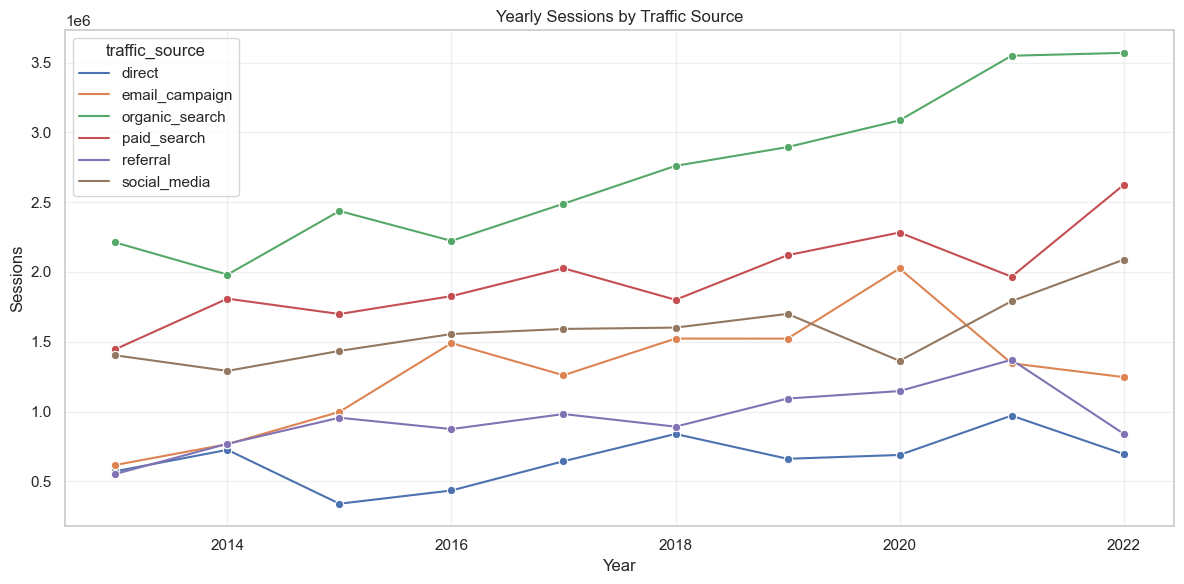

In [ ]:
# 5) Sessions by traffic source over time
web_traffic['date'] = pd.to_datetime(web_traffic['date'])
web_traffic['Year'] = web_traffic['date'].dt.year

source_yearly = web_traffic.groupby(['Year', 'traffic_source'], as_index=False)['sessions'].sum()

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=source_yearly,
    x='Year',
    y='sessions',
    hue='traffic_source',
    marker='o'
)

plt.title('Yearly Sessions by Traffic Source')
plt.xlabel('Year')
plt.ylabel('Sessions')
plt.grid(alpha=0.3)
plt.tight_layout()
save_business('sessions_by_traffic_source')
plt.show()

Organic là nguồn lớn nhất, các nguồn traffic khác  đều tăng hoặc nhiến động không nhiều.


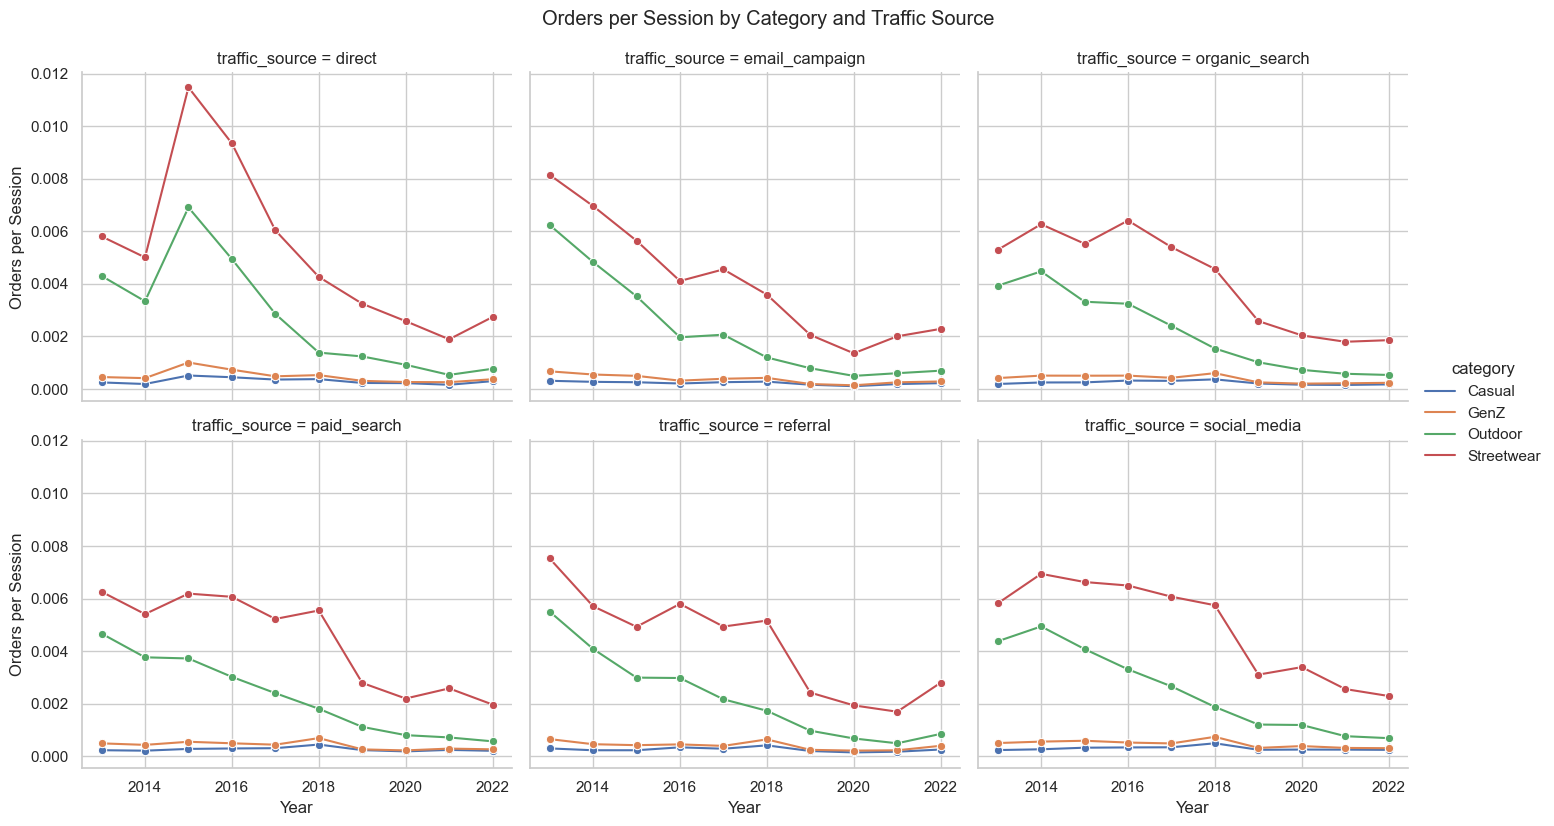

In [ ]:
# 6) Orders per session by category and traffic source
orders['order_date'] = pd.to_datetime(orders['order_date'], errors='coerce')
web_traffic['date'] = pd.to_datetime(web_traffic['date'], errors='coerce')

orders_with_year = orders.assign(Year=orders['order_date'].dt.year).rename(columns={'order_source': 'traffic_source'})
order_items_with_category = order_items.merge(
    products[['product_id', 'category']],
    on='product_id',
    how='left'
)
order_items_with_orders = order_items_with_category.merge(
    orders_with_year[['order_id', 'Year', 'traffic_source']],
    on='order_id',
    how='left'
)

orders_cat_source = order_items_with_orders.groupby(['Year', 'traffic_source', 'category'], as_index=False).agg(
    orders=('order_id', 'nunique'),
    quantity=('quantity', 'sum')
)

sessions_source_year = web_traffic.assign(Year=web_traffic['date'].dt.year).groupby(
    ['Year', 'traffic_source'],
    as_index=False
).agg(
    sessions=('sessions', 'sum')
)

cat_source_conv = orders_cat_source.merge(
    sessions_source_year,
    on=['Year', 'traffic_source'],
    how='left'
)

cat_source_conv['orders_per_session'] = np.where(
    cat_source_conv['sessions'] > 0,
    cat_source_conv['orders'] / cat_source_conv['sessions'],
    np.nan
)

cat_source_conv['quantity_per_session'] = np.where(
    cat_source_conv['sessions'] > 0,
    cat_source_conv['quantity'] / cat_source_conv['sessions'],
    np.nan
)

g = sns.relplot(
    data=cat_source_conv,
    x='Year',
    y='orders_per_session',
    hue='category',
    col='traffic_source',
    col_wrap=3,
    kind='line',
    marker='o',
    height=4,
    aspect=1.2
)

g.fig.suptitle('Orders per Session by Category and Traffic Source', y=1.03)
g.set_axis_labels('Year', 'Orders per Session')
save_business('orders_per_session_by_category_and_traffic_source')
plt.show()

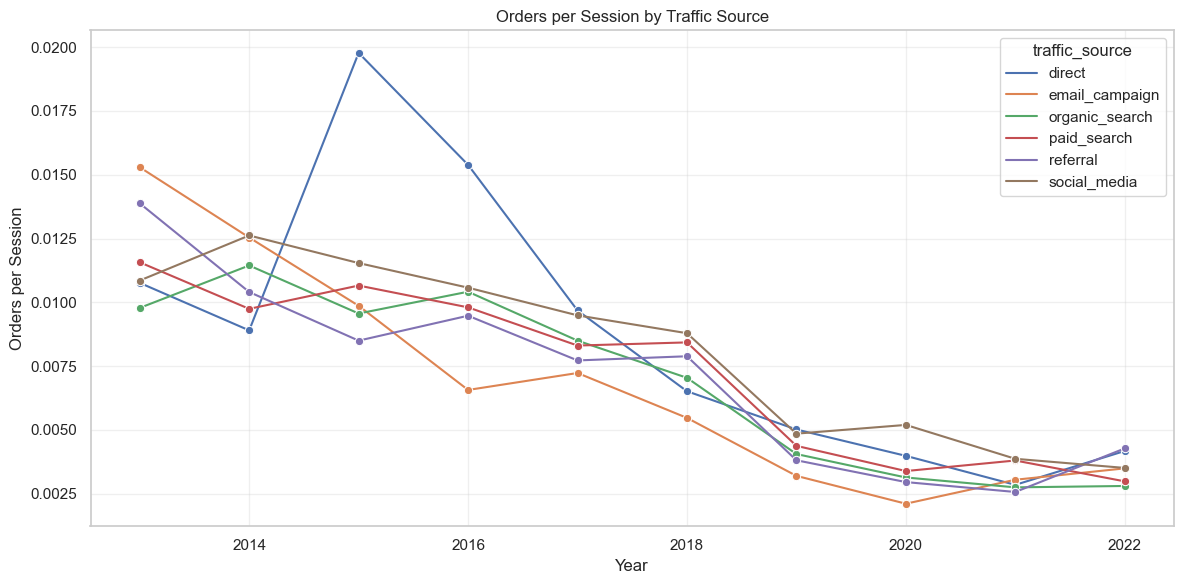

In [ ]:
# 7) Orders per session by traffic source
orders['order_date'] = pd.to_datetime(orders['order_date'], errors='coerce')
web_traffic['date'] = pd.to_datetime(web_traffic['date'], errors='coerce')

traffic_source = web_traffic.assign(Year=web_traffic['date'].dt.year).groupby(['Year', 'traffic_source'], as_index=False).agg(
    sessions=('sessions', 'sum')
)

orders_source = orders.assign(
    Year=orders['order_date'].dt.year
).groupby(['Year', 'order_source'], as_index=False).agg(
    orders=('order_id', 'nunique')
).rename(columns={'order_source': 'traffic_source'})

conv_source = traffic_source.merge(
    orders_source,
    on=['Year', 'traffic_source'],
    how='left'
)

conv_source['orders'] = conv_source['orders'].fillna(0)
conv_source['orders_per_session'] = np.where(
    conv_source['sessions'] > 0,
    conv_source['orders'] / conv_source['sessions'],
    np.nan
)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=conv_source,
    x='Year',
    y='orders_per_session',
    hue='traffic_source',
    marker='o'
)

plt.title('Orders per Session by Traffic Source')
plt.xlabel('Year')
plt.ylabel('Orders per Session')
plt.grid(alpha=0.3)
plt.tight_layout()
save_business('orders_per_session_by_traffic_source')
plt.show()

Suy giảm CR toàn bộ traffic source, không phải một nguồn riêng lẻ 
**=> Vấn đề hệ thống.**
Giảm mạnh ở Streetwear, Outdoor. Nhìn vào cũng thấy, doanh nghiệp đang phụ thuộc mạnh vào 1 nhóm danh mục chủ lực. 

### 1.6. Lý do trả hàng

,return_reason,count,share
0,wrong_size,13967,0.349708
1,defective,8020,0.200806
2,not_as_described,7035,0.176144
3,changed_mind,6931,0.173540
4,late_delivery,3986,0.099802


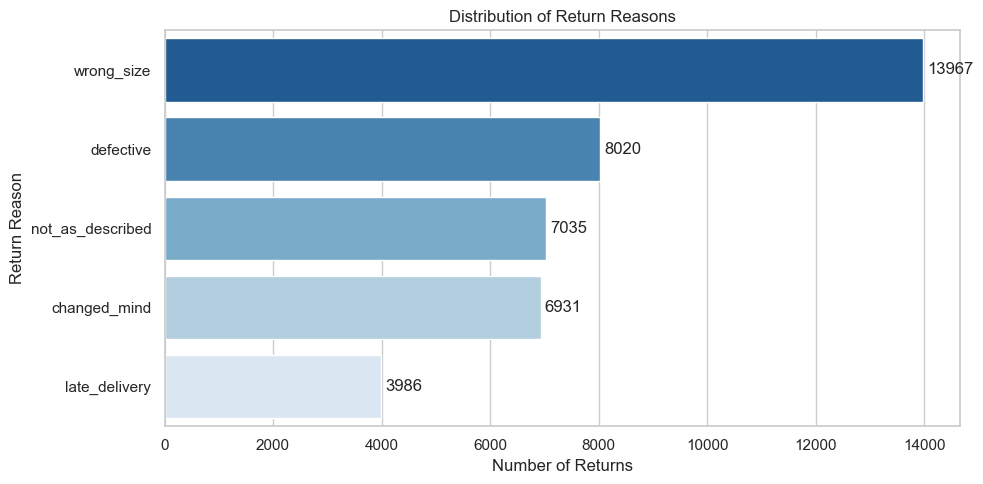

In [ ]:
# return reason distribution
return_reason_stats = (
    returns['return_reason']
    .fillna('unknown')
    .str.strip()
    .str.lower()
    .value_counts()
    .reset_index()
)
return_reason_stats.columns = ['return_reason', 'count']
return_reason_stats['share'] = return_reason_stats['count'] / return_reason_stats['count'].sum()

display(return_reason_stats)

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=return_reason_stats, y='return_reason', x='count', palette='Blues_r')

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)

ax.set_title('Distribution of Return Reasons')
ax.set_xlabel('Number of Returns')
ax.set_ylabel('Return Reason')
plt.tight_layout()
save_business('return_reason_distribution')
plt.show()

Trong các lý do trả hàng, **sai kích cỡ** là lý do có số lượng chiếm nhiều nhất. Cao gấp đôi so với các lý do còn lại => Doanh nghiệp đang gặp vấn đề sản phẩm.

## 2. Câu hỏi kinh doanh

* **Câu hỏi 4, 5, 6 được suy luận từ EDA notebook 04**


1. Vì sao doanh thu bắt đầu suy giảm từ năm 2019 và đâu là nguyên nhân tạo ra điểm gãy tăng trưởng này? Vì sao số lượng đơn hàng giảm trong khi AOV lại tăng?

2. Vì sao biên lợi nhuận biến động mạnh qua các năm và không đồng nhất với xu hướng doanh thu?

3. Vì sao lượng truy cập website vẫn tăng nhưng doanh thu và tỷ lệ Conversion Rate lại giảm? Wrong Size" là nguyên nhân trả hàng lớn nhất?

4. Liệu Streetwear và Outdoor thực sự là động lực tăng trưởng bền vững, hay đây là hai danh mục mà doanh nghiệp đang phụ thuộc quá trình khi hiệu quả chuyển đổi đang mòn dần? GenZ đi đến Casual có phải là cơ hội chưa được khai thác thác?

5. Vì sao "Wrong Size" trở thành nguyên nhân trả hàng phổ biến nhất và mức độ ảnh hưởng của vấn đề này đến doanh thu ròng là bao nhiêu?

6. Liệu logistics có phải là yếu tố giải thích sự khác biệt về hiệu quả kinh doanh giữa các khu vực? Các khu vực có chi phí vận chuyển cao hơn có ghi nhận doanh thu trên mỗi khách hàng hoặc tỷ lệ mua lại thấp hơn hay không?



## 3. Phân tích các vấn đề cốt lõi (Diagnostic)

- Vấn đề 1. Revenue giảm vì conversion giảm, bằng chứng ở các biểu đồ tổng quan

- Vấn đề 2. AOV tăng là tín hiệu sản phẩm bị đẩy giá, không hẳn là tín hiệu tốt

- Vấn đề 3. Conversion rate giảm, nguyên nhân từ đâu?

**Vấn đề chung lớn nhất:** Công thức tính Doanh thu của doanh nghiệp:
=> Revenue=Sessions×Conversion Rate×AOV

Mà Sessions tăng, AOV tăng, nhưng Orders (CR) giảm mạnh => kéo sập Revenue chính là: **Orders per Session.**


### 3.1. Vì sao năm 2019 là điểm gãy doanh thu?

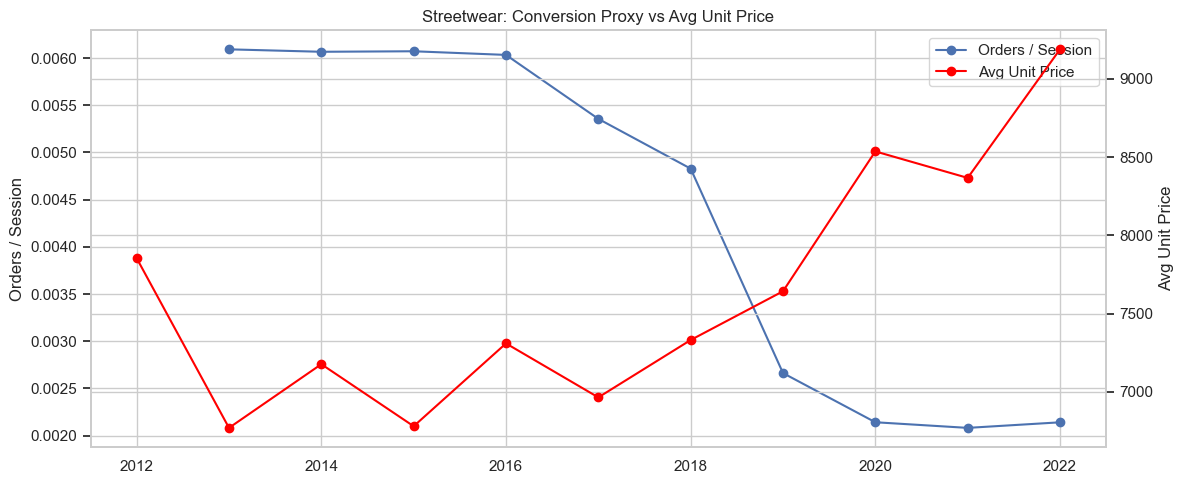

In [ ]:
order_items_with_category = order_items.merge(
    products[['product_id', 'category', 'cogs']],
    on='product_id',
    how='left'
)

order_items_with_orders = order_items_with_category.merge(
    orders[['order_id', 'order_date', 'order_source']],
    on='order_id',
    how='left'
)

order_items_with_orders['order_date'] = pd.to_datetime(order_items_with_orders['order_date'], errors='coerce')
valid_items = order_items_with_orders.copy()
valid_items['Year'] = valid_items['order_date'].dt.year
valid_items['gross_revenue'] = valid_items['quantity'] * valid_items['unit_price'] - valid_items['discount_amount'].fillna(0)
valid_items['gross_profit'] = valid_items['gross_revenue'] - (valid_items['quantity'] * valid_items['cogs'])

sessions_year = web_traffic.copy()
sessions_year['date'] = pd.to_datetime(sessions_year['date'], errors='coerce')
sessions_year['Year'] = sessions_year['date'].dt.year
sessions_year = sessions_year.groupby('Year', as_index=False).agg(
    sessions=('sessions', 'sum')
)

street = valid_items[valid_items['category'] == 'Streetwear'].copy()

street_year = street.groupby('Year', as_index=False).agg(
    orders=('order_id', 'nunique'),
    quantity=('quantity', 'sum'),
    revenue=('gross_revenue', 'sum'),
    profit=('gross_profit', 'sum'),
    avg_unit_price=('unit_price', 'mean'),
    discount=('discount_amount', 'sum')
)

street_year = street_year.merge(sessions_year, on='Year', how='left')
street_year['orders_per_session'] = street_year['orders'] / street_year['sessions']
street_year['revenue_per_session'] = street_year['revenue'] / street_year['sessions']
street_year['profit_per_session'] = street_year['profit'] / street_year['sessions']
street_year['discount_rate'] = street_year['discount'] / (street_year['revenue'] + street_year['discount'])
street_year['items_per_order'] = street_year['quantity'] / street_year['orders']

fig, ax1 = plt.subplots(figsize=(12,5))
ax1.plot(street_year['Year'], street_year['orders_per_session'], marker='o', label='Orders / Session')
ax1.set_ylabel('Orders / Session')

ax2 = ax1.twinx()
ax2.plot(street_year['Year'], street_year['avg_unit_price'], marker='o', color='red', label='Avg Unit Price')
ax2.set_ylabel('Avg Unit Price')

plt.title('Streetwear: Conversion Proxy vs Avg Unit Price')
h1,l1 = ax1.get_legend_handles_labels()
h2,l2 = ax2.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2)
plt.tight_layout()
save_business('streetwear_conversion_vs_price_trend')
plt.show()

Như đã phân tích từ Notebook 03 (Sản phẩm), công ty phụ thuộc quá nhiều vào 1 sản phẩm chủ lực là Streetwear. => Từ năm 2019, **tăng mạnh giá streetwear** dẫn tới giảm volume, tạo ra điểm gãy doanh thu lớn nhất.


### 3.2. Vì sao biên lợi nhuận thay đổi bất thường và không đồng nhất với doanh thu? 

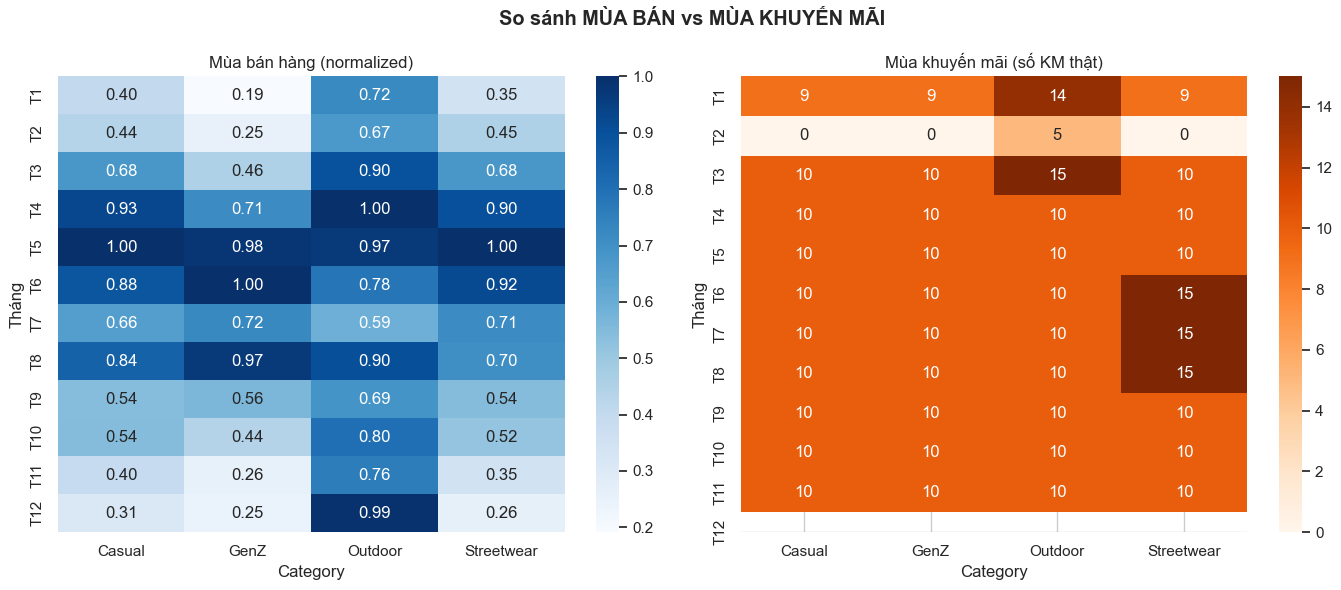

In [ ]:
orders = orders.copy()
order_items = order_items.copy()
products = products.copy()
promotions = promotions.copy()


oi = order_items.merge(
    orders[['order_id', 'order_date']],
    on='order_id',
    how='left'
)

oi = oi.merge(
    products[['product_id', 'category']],
    on='product_id',
    how='left'
)

oi['order_date'] = pd.to_datetime(oi['order_date'], errors='coerce')
oi['month'] = oi['order_date'].dt.month

if 'revenue' not in oi.columns:
    oi['revenue'] = oi['unit_price'] * oi['quantity'] - oi.get('discount_amount', 0)

rev_month = oi.groupby(['month', 'category'])['revenue'].sum().unstack().fillna(0)

rev_norm = rev_month.div(rev_month.max())


promotions['start_date'] = pd.to_datetime(promotions['start_date'], errors='coerce')
promotions['end_date'] = pd.to_datetime(promotions['end_date'], errors='coerce')

promo_items = order_items.merge(
    promotions[['promo_id', 'start_date', 'end_date']],
    on='promo_id',
    how='inner'
)

promo_items = promo_items.merge(
    products[['product_id', 'category']],
    on='product_id',
    how='left'
)

promo_months = []

for _, row in promo_items.iterrows():
    if pd.isna(row['start_date']) or pd.isna(row['end_date']):
        continue

    months = pd.period_range(
        start=row['start_date'].to_period('M'),
        end=row['end_date'].to_period('M'),
        freq='M'
    )

    for m in months:
        promo_months.append({
            'month': m.month,
            'category': row['category'],
            'promo_id': row['promo_id']
        })

promo_df = pd.DataFrame(promo_months)

if not promo_df.empty:
    promo_month = promo_df.groupby(['month', 'category'])['promo_id'].nunique().unstack().fillna(0)
else:
    promo_month = pd.DataFrame(index=range(1, 13))


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(
    rev_norm,
    cmap='Blues',
    annot=True,
    fmt='.2f',
    ax=axes[0],
    yticklabels=[f'T{i}' for i in range(1, 13)]
)

axes[0].set_title('Mùa bán hàng (normalized)')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Tháng')

if not promo_month.empty:
    sns.heatmap(
        promo_month,
        cmap='Oranges',
        annot=True,
        fmt='.0f',
        ax=axes[1],
        yticklabels=[f'T{i}' for i in range(1, 13)]
    )
else:
    axes[1].set_axis_off()
    axes[1].set_title('Mùa khuyến mãi (không có dữ liệu)')

axes[1].set_title('Mùa khuyến mãi (số KM thật)')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Tháng')

plt.suptitle('So sánh MÙA BÁN vs MÙA KHUYẾN MÃI', fontweight='bold')
plt.tight_layout()
save_business('seasonality_revenue_vs_promotion')
plt.show()

Dữ liệu tổng doanh thu và tổng số khuyến mãi theo tháng:


,month,total_revenue,total_promotions,month_name
0,1,7.964305e+08,41.0,Jan
1,2,9.692912e+08,5.0,Feb
2,3,1.433761e+09,45.0,Mar
3,4,1.859505e+09,40.0,Apr
4,5,2.038379e+09,0.0,May
5,6,1.852845e+09,40.0,Jun
6,7,1.429122e+09,45.0,Jul
7,8,1.508954e+09,45.0,Aug
8,9,1.148765e+09,45.0,Sep
9,10,1.122944e+09,40.0,Oct


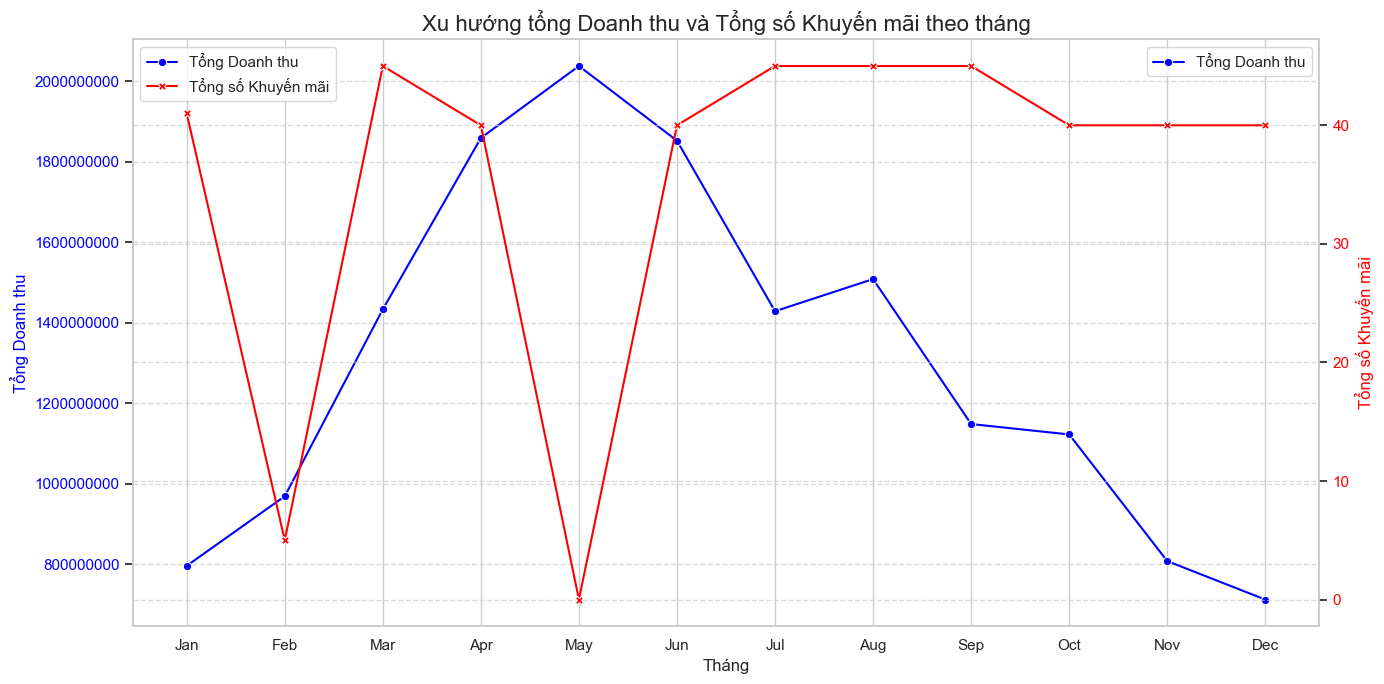

In [ ]:
# Compute total monthly revenue. Build a safe series regardless of input type.
if isinstance(rev_month, pd.DataFrame):
    total_series = rev_month.sum(axis=1)
else:
    total_series = rev_month.copy()

# Extract month numbers from the index robustly
try:
    months_idx = total_series.index.astype(int)
except Exception:
    try:
        months_idx = pd.to_datetime(total_series.index).month
    except Exception:
        months_idx = list(range(1, len(total_series) + 1))

total_monthly_revenue = pd.DataFrame({
    'month': list(months_idx),
    'total_revenue': list(total_series.values)
})

# Compute total monthly promotions. Handle empty promo_month gracefully.
if isinstance(promo_month, pd.DataFrame) and not promo_month.empty:
    promo_series = promo_month.sum(axis=1)
    try:
        promo_months_idx = promo_series.index.astype(int)
    except Exception:
        try:
            promo_months_idx = pd.to_datetime(promo_series.index).month
        except Exception:
            promo_months_idx = list(range(1, len(promo_series) + 1))

    total_monthly_promotions = pd.DataFrame({
        'month': list(promo_months_idx),
        'total_promotions': list(promo_series.values)
    })
else:
    total_monthly_promotions = pd.DataFrame({'month': list(range(1, 13)), 'total_promotions': 0})

# Merge these two dataframes and fill missing values
monthly_summary = pd.merge(total_monthly_revenue, total_monthly_promotions, on='month', how='outer')
monthly_summary['total_revenue'] = monthly_summary['total_revenue'].fillna(0)
monthly_summary['total_promotions'] = monthly_summary['total_promotions'].fillna(0)

# Ensure month is integer and sorted
monthly_summary['month'] = monthly_summary['month'].astype(int)
monthly_summary = monthly_summary.sort_values('month').reset_index(drop=True)

# Map month number to abbreviated month name and keep correct order
month_order = [datetime.date(1900, m, 1).strftime('%b') for m in range(1, 13)]
monthly_summary['month_name'] = monthly_summary['month'].apply(lambda x: datetime.date(1900, x, 1).strftime('%b'))

print("Dữ liệu tổng doanh thu và tổng số khuyến mãi theo tháng:")
display(monthly_summary)

# Create the plot (use numeric month for x to preserve ordering)
fig, ax1 = plt.subplots(figsize=(14, 7))

sns.lineplot(x='month', y='total_revenue', data=monthly_summary, marker='o', color='blue', ax=ax1, label='Tổng Doanh thu')
ax1.set_xlabel('Tháng', fontsize=12)
ax1.set_ylabel('Tổng Doanh thu', color='blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='blue')
ax1.ticklabel_format(style='plain', axis='y')
ax1.grid(axis='y', linestyle='--', alpha=0.7)
ax1.set_xticks(list(range(1, 13)))
ax1.set_xticklabels(month_order)

# Second axis for promotions
ax2 = ax1.twinx()
sns.lineplot(x='month', y='total_promotions', data=monthly_summary, marker='X', color='red', ax=ax2, label='Tổng số Khuyến mãi')
ax2.set_ylabel('Tổng số Khuyến mãi', color='red', fontsize=12)
ax2.grid(axis='y', linestyle='--', alpha=0.7)
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Xu hướng tổng Doanh thu và Tổng số Khuyến mãi theo tháng', fontsize=16)

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
save_business('monthly_revenue_promotion_trend')
plt.show()

#### Phân tích chiến lược khuyến mãi & Profit Margin

1. Sai lệch về timing khuyến mãi: Khuyến mãi không được triển khai vào đúng thời điểm nhu cầu cao nhất. T5 hoàn toàn không có KM dù doanh thu tăng mạnh, trong khi T7–T9 vẫn duy trì nhiều chương trình dù nhu cầu đã giảm, làm discount cost tăng nhưng không tạo thêm tăng trưởng, từ đó kéo giảm profit margin.

2. Chiến lược khuyến mãi dàn trải: Khuyến mãi được triển khai gần như xuyên suốt năm và cho nhiều danh mục cùng lúc thay vì tập trung vào các giai đoạn chiến lược. Ví dụ T2 chỉ có 5 chương trình Rural Special nên không đủ tạo hiệu ứng doanh thu rõ rệt.

3. Hiệu quả khuyến mãi phụ thuộc mạnh vào timing: T3 đẩy mạnh khuyến mãi giúp doanh thu T4–T5 tăng mạnh, cho thấy tồn tại hiệu ứng trễ. Ngược lại, T7–T9 vẫn có nhiều khuyến mãi nhưng doanh thu tiếp tục giảm, chứng minh khuyến mãi chỉ hiệu quả khi đi trước nhu cầu thị trường.

4. Các năm lẻ có biên lợi nhuận yếu hơn: Năm lẻ triển khai thêm Urban và Rural cho Streetwear và Outdoor, làm tăng mức độ discount. Urban là chương trình clearance diễn ra từ 30/08–02/09 và trùng với Fall Launch, có thể khiến khách hàng ưu tiên hàng giảm giá thay vì collection mới, từ đó làm giảm tỷ lệ bán full-price và kéo giảm margin.

5. Tăng giá để bù margin tạo phản ứng ngược: Sau 2017, Streetwear và Outdoor bắt đầu tăng giá để bù lượng đơn hàng giảm. Tuy nhiên điều này lại mâu thuẫn với mục tiêu clearance là bán nhanh với giá thấp để thu hồi vốn, đồng thời có thể làm conversion rate và số lượng đơn tiếp tục giảm.

6. Các năm chẵn chưa có đổi mới về khuyến mãi: So với năm lẻ, năm chẵn không có thêm chương trình mới đáng kể, khiến chiến lược promotion trở nên lặp lại và thiếu động lực tăng trưởng dài hạn.


**=> Biên lợi nhuận ở các năm lẻ suy yếu chủ yếu do doanh nghiệp tăng cường khuyến mãi nhưng chưa tối ưu về timing và chiến lược triển khai. Việc discount kéo dài, clearance chồng chéo với launch campaign và tăng giá để bù margin khiến doanh thu không tăng đủ để bù lại phần lợi nhuận bị mất.**

### 3.3. Vì sao traffic tăng nhưng doanh thu lại giảm ở năm 2019? Tỷ lệ conversion giảm?

Ma trận đếm số lượng sản phẩm theo Kích cỡ và Màu sắc:


color,black,blue,green,orange,pink,purple,red,silver,white,yellow
size,,,,,,,,,,
L,0,0,121,121,120,0,121,0,120,0
M,121,120,0,0,0,121,0,120,0,121
S,0,0,120,121,121,0,120,0,121,0
XL,121,121,0,0,0,120,0,121,0,120


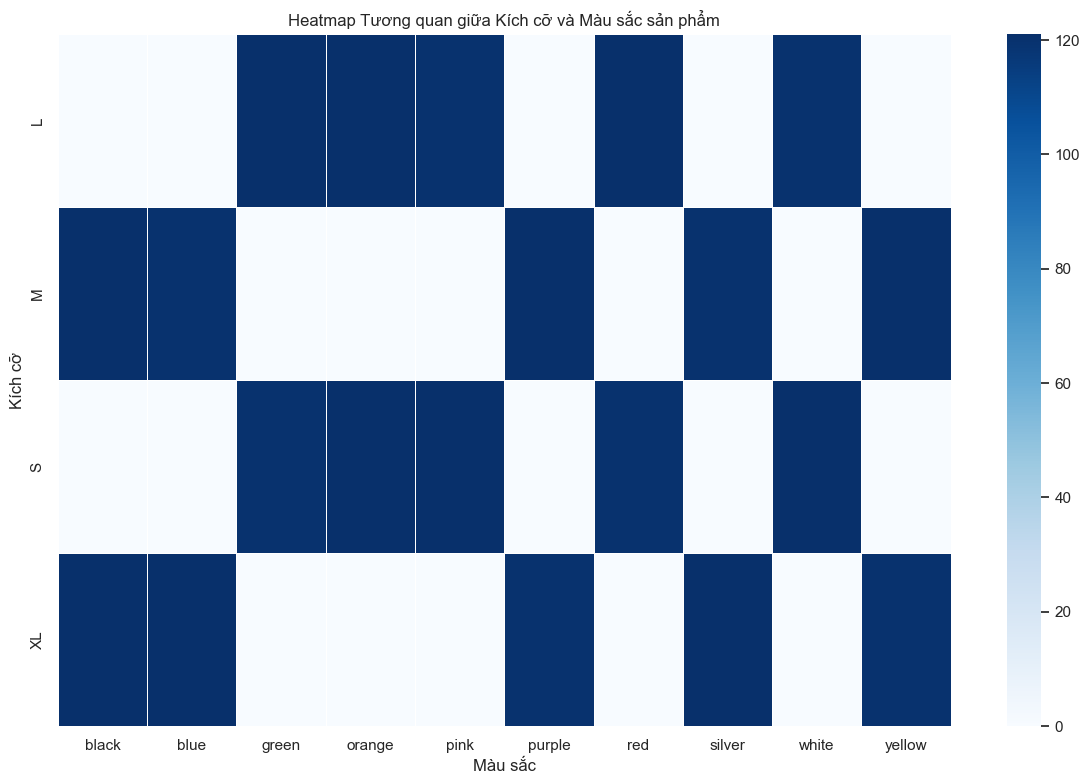

In [ ]:
# copy dataframe
products_df = products.copy()

# Create size-color matrix
size_color_counts = (
    products_df
    .groupby(['size', 'color'])
    .size()
    .unstack(fill_value=0)
)

print("Ma trận đếm số lượng sản phẩm theo Kích cỡ và Màu sắc:")
display(size_color_counts.head())

# Heatmap visualization
plt.figure(figsize=(12, 8))

sns.heatmap(
    size_color_counts,
    annot=False,
    cmap='Blues',
    linewidths=.5
)

plt.title('Heatmap Tương quan giữa Kích cỡ và Màu sắc sản phẩm')
plt.xlabel('Màu sắc')
plt.ylabel('Kích cỡ')

plt.tight_layout()
save_business('size_color_correlation_heatmap')
plt.show()

Phân tích cho thấy doanh nghiệp đang áp dụng cơ chế **“khóa màu theo size”**, tức mỗi nhóm kích cỡ chỉ được bán với một tập màu cố định thay vì cho phép toàn bộ màu xuất hiện ở mọi size.

- **Size L và S** chỉ bán các màu: `green`, `orange`, `pink`, `red`, `white`.
- **Size XL và M** chỉ bán các màu: `black`, `blue`, `purple`, `silver`, `yellow`.

#### Tác động

- Giảm khả năng khách hàng tìm được đúng combination **size + màu** mong muốn.
- Làm giảm trải nghiệm mua hàng và tỷ lệ conversion.
- Có thể là nguyên nhân khiến **“Wrong size”** trở thành lý do trả hàng phổ biến nhất.
- Dù web traffic ổn định, khách hàng vẫn khó chốt đơn do lựa chọn sản phẩm bị giới hạn.

### 3.4. Liệu Streetwear và Outdoor thực sự là động lực tăng trưởng bền vững, hay đây là hai danh mục mà doanh nghiệp đang phụ thuộc quá trình khi hiệu quả chuyển đổi đang mòn dần? GenZ đi đến Casual có phải là cơ hội chưa được khai thác thác?


***   **Biểu đồ trực quan ở Dashboard Product: reports\powerbi\Dashboard.pbix**


Kết quả phân tích cho thấy **Streetwear** và **Outdoor** vẫn là hai danh mục có khả năng chuyển đổi khách hàng tốt nhất, nhưng đồng thời cũng ghi nhận xu hướng suy giảm Conversion Rate theo thời gian. Đáng chú ý, Streetwear là danh mục có **doanh thu thất thoát do hoàn trả lớn nhất**, trong khi Outdoor có **tỷ lệ thất thoát doanh thu cao nhất (8.08%)**, cho thấy hiệu quả của hai nhóm sản phẩm chủ lực đang suy giảm cả ở giai đoạn chuyển đổi lẫn sau bán hàng.

Ngược lại, **Casual** và **GenZ** cho thấy nhiều tín hiệu tăng trưởng tích cực. Casual đạt **tốc độ tăng trưởng cao nhất (37.85%)**, trong khi GenZ tăng trưởng **26.62%**, sở hữu **biên lợi nhuận gộp cao nhất (20.16%)** và ghi nhận **tỷ lệ hết hàng cao nhất (68.29%)** dù có số lượng SKU thấp nhất. Điều này cho thấy nhu cầu đối với GenZ có thể đang vượt quá khả năng cung ứng hiện tại.

Nhìn chung, doanh nghiệp đang phụ thuộc đáng kể vào các danh mục có dấu hiệu suy giảm hiệu quả, trong khi các danh mục có tốc độ tăng trưởng và khả năng sinh lời cao hơn vẫn chưa được khai thác tương xứng. Đây có thể là cơ hội để tái phân bổ nguồn lực nhằm thúc đẩy tăng trưởng bền vững trong tương lai.

### 3.5. Vì sao "Wrong Size" trở thành nguyên nhân trả hàng phổ biến nhất và mức độ ảnh hưởng của vấn đề này đến doanh thu ròng là bao nhiêu?

REVENUE IMPACT BY CATEGORY


,revenue_lost,return_count,total_revenue,revenue_loss_pct
category,,,,
Outdoor,1.902080e+08,11293,2.353397e+09,8.08
GenZ,1.923986e+07,2120,3.287102e+08,5.85
Casual,2.567724e+07,1272,4.402852e+08,5.83
Streetwear,7.083316e+08,21596,1.255848e+10,5.64


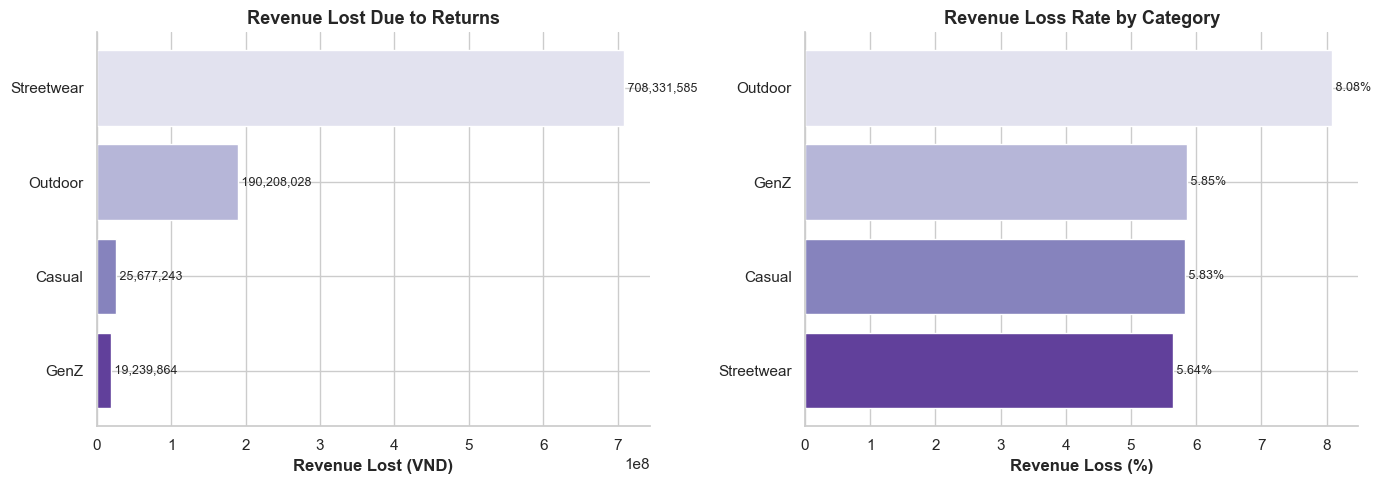


OVERALL REVENUE IMPACT
----------------------------------------
Total Revenue Lost : 943,456,719.02 VND
Total Revenue      : 15,680,869,265.43 VND
Revenue Loss Rate  : 6.02%


In [15]:
# Revenue Impact Analysis: Revenue lost due to returns by category
ret = returns.copy()
# Merge returns with order items
return_items = (
    ret[['order_id', 'refund_amount', 'return_date', 'return_reason']]
    .merge(
        order_items[
            ['order_id', 'product_id', 'quantity',
             'unit_price', 'discount_amount']
        ],
        on='order_id',
        how='left'
    )
)

# Add category information
return_items = return_items.merge(
    products[['product_id', 'category']],
    on='product_id',
    how='left'
)

# Calculate lost revenue per item
return_items['item_revenue'] = (
    return_items['quantity'] * return_items['unit_price']
    - return_items['discount_amount'].fillna(0)
)

# Revenue lost by category
revenue_lost_by_category = (
    return_items
    .groupby('category')
    .agg(
        revenue_lost=('item_revenue', 'sum'),
        return_count=('order_id', 'nunique')
    )
)

# Total revenue by category
all_items = order_items.merge(
    products[['product_id', 'category']],
    on='product_id'
)

all_items['item_revenue'] = (
    all_items['quantity'] * all_items['unit_price']
    - all_items['discount_amount'].fillna(0)
)

total_revenue_by_category = (
    all_items.groupby('category')['item_revenue'].sum()
)

# Add metrics
revenue_lost_by_category['total_revenue'] = total_revenue_by_category

revenue_lost_by_category['revenue_loss_pct'] = (
    revenue_lost_by_category['revenue_lost']
    / revenue_lost_by_category['total_revenue']
    * 100
)

print("REVENUE IMPACT BY CATEGORY")
print("=" * 90)

display(
    revenue_lost_by_category
    .sort_values('revenue_loss_pct', ascending=False)
    .round(2)
)

# ==========================================================
# Visualization
# ==========================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Purple palettes
colors1 = sns.color_palette(
    "Purples_r",
    len(revenue_lost_by_category)
)

colors2 = sns.color_palette(
    "Purples_r",
    len(revenue_lost_by_category)
)

# Chart 1: Revenue Lost
sorted_data = revenue_lost_by_category.sort_values(
    'revenue_lost',
    ascending=True
)

axes[0].barh(
    sorted_data.index,
    sorted_data['revenue_lost'],
    color=colors1
)

axes[0].set_title(
    'Revenue Lost Due to Returns',
    fontsize=13,
    fontweight='bold'
)

axes[0].set_xlabel(
    'Revenue Lost (VND)',
    fontweight='bold'
)

for i, v in enumerate(sorted_data['revenue_lost']):
    axes[0].text(
        v,
        i,
        f' {v:,.0f}',
        va='center',
        fontsize=9
    )

# Chart 2: Revenue Loss Rate
sorted_pct = revenue_lost_by_category.sort_values(
    'revenue_loss_pct',
    ascending=True
)

axes[1].barh(
    sorted_pct.index,
    sorted_pct['revenue_loss_pct'],
    color=colors2
)

axes[1].set_title(
    'Revenue Loss Rate by Category',
    fontsize=13,
    fontweight='bold'
)

axes[1].set_xlabel(
    'Revenue Loss (%)',
    fontweight='bold'
)

for i, v in enumerate(sorted_pct['revenue_loss_pct']):
    axes[1].text(
        v,
        i,
        f' {v:.2f}%',
        va='center',
        fontsize=9
    )

sns.despine()

plt.tight_layout()

save_business('revenue_impact_by_category')

plt.show()

# ==========================================================
# Overall Impact
# ==========================================================

total_revenue_lost = revenue_lost_by_category['revenue_lost'].sum()

total_revenue_all = revenue_lost_by_category['total_revenue'].sum()

overall_revenue_loss_pct = (
    total_revenue_lost / total_revenue_all * 100
)

print("\nOVERALL REVENUE IMPACT")
print("-" * 40)
print(f"Total Revenue Lost : {total_revenue_lost:,.2f} VND")
print(f"Total Revenue      : {total_revenue_all:,.2f} VND")
print(f"Revenue Loss Rate  : {overall_revenue_loss_pct:.2f}%")

Dựa trên kết quả ở Câu 3, **Wrong Size** là nguyên nhân trả hàng phổ biến nhất, phản ánh tình trạng **"khóa màu theo size"** khiến khách hàng khó lựa chọn đúng sản phẩm phù hợp.

Mặc dù tỷ lệ trả hàng của doanh nghiệp chỉ ở mức **5.57%**, tác động đến doanh thu lại khá đáng kể. Từ **15.68 tỷ đồng Gross Revenue**, doanh nghiệp chỉ giữ lại khoảng **14.74 tỷ đồng Net Revenue** sau khi trừ các đơn hàng hoàn trả. Điều này tương đương **943 triệu đồng doanh thu bị mất**, chiếm **6.02% tổng doanh thu**.

Kết quả cho thấy doanh thu ghi nhận ban đầu có thể phản ánh cao hơn hiệu quả kinh doanh thực tế. Do đó, việc đánh giá hiệu quả kinh doanh chỉ dựa trên **Gross Revenue** có thể dẫn đến cái nhìn chưa đầy đủ về giá trị thực sự mà doanh nghiệp giữ lại.

Xét theo danh mục sản phẩm, **Streetwear** ghi nhận mức doanh thu bị mất lớn nhất với hơn **708 triệu đồng** do sở hữu quy mô doanh thu vượt trội. Tuy nhiên, xét theo tỷ lệ thất thoát, **Outdoor** mới là danh mục đáng chú ý nhất khi mất tới **8.08% doanh thu**, cao hơn đáng kể so với **Streetwear (5.64%)**. Điều này cho thấy Outdoor đang đối mặt với rủi ro hoàn trả cao hơn và là nhóm sản phẩm cần được ưu tiên cải thiện về chất lượng, thông tin sản phẩm hoặc trải nghiệm mua sắm nhằm giảm thất thoát doanh thu.

NET REVENUE ANALYSIS BY REGION


,Gross Revenue,Revenue Lost (Returns),Net Revenue,Loss %
region,,,,
Central,4.719491e+09,2.590153e+08,4.460476e+09,5.49
East,7.291151e+09,3.967350e+08,6.894416e+09,5.44
West,3.670227e+09,2.084041e+08,3.461823e+09,5.68


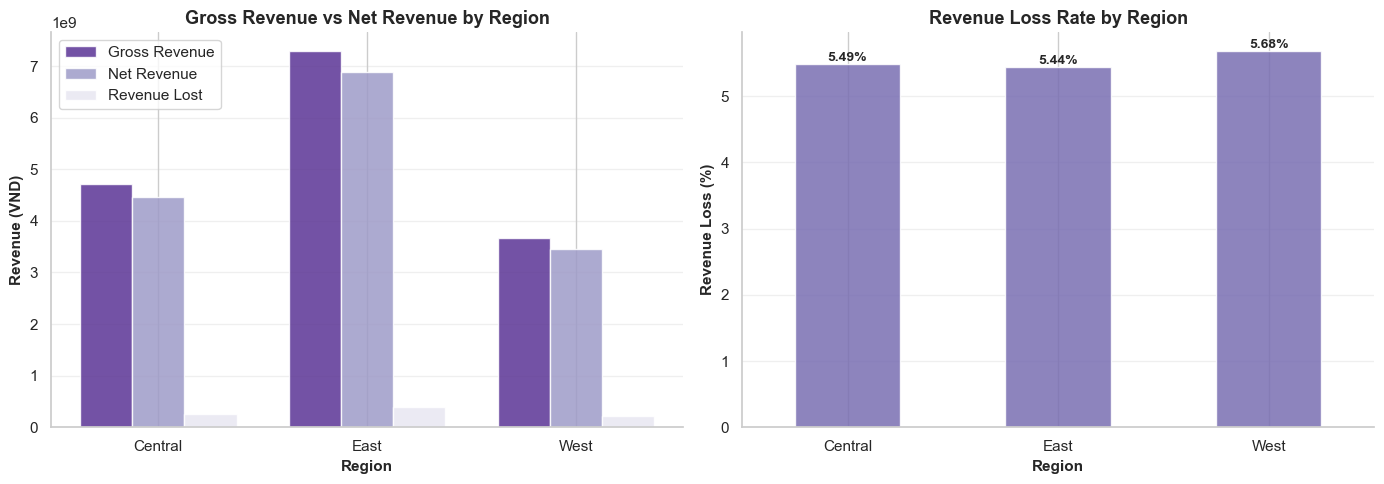


OVERALL COMPANY PERFORMANCE
----------------------------------------
Gross Revenue     : 15,680,869,265.43 VND
Net Revenue       : 14,816,714,794.08 VND
Revenue Lost      : 864,154,471.35 VND
Revenue Loss Rate : 5.51%
Revenue Retained  : 94.49%


In [16]:
# ==========================================================
# Build revenue dataset
# ==========================================================

# Revenue per order item
revenue_data = (
    order_items
    .copy()
)

revenue_data['item_revenue'] = (
    revenue_data['quantity']
    * revenue_data['unit_price']
    - revenue_data['discount_amount'].fillna(0)
)

# Add customer + region
revenue_data = (
    revenue_data
    .merge(
        orders[['order_id', 'customer_id', 'zip']],
        on='order_id',
        how='left'
    )
    .merge(
        geography[['zip', 'region']],
        on='zip',
        how='left'
    )
)

# ==========================================================
# Gross revenue by region
# ==========================================================

gross_revenue = (
    revenue_data
    .groupby('region')['item_revenue']
    .sum()
)

# ==========================================================
# Revenue lost due to returns
# ==========================================================

returned_orders = set(ret['order_id'])

returned_revenue = (
    revenue_data[
        revenue_data['order_id'].isin(returned_orders)
    ]
    .groupby('region')['item_revenue']
    .sum()
)

# ==========================================================
# Final comparison table
# ==========================================================

revenue_comparison = pd.DataFrame({
    'Gross Revenue': gross_revenue,
    'Revenue Lost (Returns)': returned_revenue
}).fillna(0)

revenue_comparison['Net Revenue'] = (
    revenue_comparison['Gross Revenue']
    - revenue_comparison['Revenue Lost (Returns)']
)

revenue_comparison['Loss %'] = (
    revenue_comparison['Revenue Lost (Returns)']
    / revenue_comparison['Gross Revenue']
    * 100
)

print("NET REVENUE ANALYSIS BY REGION")
print("=" * 90)

display(revenue_comparison.round(2))

# ==========================================================
# Visualization
# ==========================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

palette = sns.color_palette("Purples_r", 5)

# Chart 1: Gross vs Net vs Revenue Lost
x = range(len(revenue_comparison))
width = 0.25

axes[0].bar(
    [i - width for i in x],
    revenue_comparison['Gross Revenue'],
    width,
    label='Gross Revenue',
    color=palette[0],
    alpha=0.85
)

axes[0].bar(
    x,
    revenue_comparison['Net Revenue'],
    width,
    label='Net Revenue',
    color=palette[2],
    alpha=0.85
)

axes[0].bar(
    [i + width for i in x],
    revenue_comparison['Revenue Lost (Returns)'],
    width,
    label='Revenue Lost',
    color=palette[4],
    alpha=0.85
)

axes[0].set_title(
    'Gross Revenue vs Net Revenue by Region',
    fontsize=13,
    fontweight='bold'
)

axes[0].set_xlabel(
    'Region',
    fontsize=11,
    fontweight='bold'
)

axes[0].set_ylabel(
    'Revenue (VND)',
    fontsize=11,
    fontweight='bold'
)

axes[0].set_xticks(list(x))
axes[0].set_xticklabels(revenue_comparison.index)

axes[0].legend(loc='upper left')
axes[0].grid(axis='y', alpha=0.3)

# ----------------------------------------------------------
# Chart 2: Revenue Loss Rate by Region

revenue_comparison['Loss %'].plot(
    kind='bar',
    ax=axes[1],
    color=palette[1],
    alpha=0.85
)

axes[1].set_title(
    'Revenue Loss Rate by Region',
    fontsize=13,
    fontweight='bold'
)

axes[1].set_xlabel(
    'Region',
    fontsize=11,
    fontweight='bold'
)

axes[1].set_ylabel(
    'Revenue Loss (%)',
    fontsize=11,
    fontweight='bold'
)

axes[1].set_xticklabels(
    revenue_comparison.index,
    rotation=0
)

for i, v in enumerate(revenue_comparison['Loss %']):
    axes[1].text(
        i,
        v,
        f'{v:.2f}%',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

axes[1].grid(axis='y', alpha=0.3)

sns.despine()

plt.tight_layout()

save_business('net_revenue_by_region')

plt.show()

# ==========================================================
# Summary Statistics
# ==========================================================

total_gross = revenue_comparison['Gross Revenue'].sum()
total_net = revenue_comparison['Net Revenue'].sum()
total_loss = revenue_comparison['Revenue Lost (Returns)'].sum()

overall_loss_pct = (
    total_loss / total_gross * 100
)

print("\nOVERALL COMPANY PERFORMANCE")
print("-" * 40)

print(f"Gross Revenue     : {total_gross:,.2f} VND")
print(f"Net Revenue       : {total_net:,.2f} VND")
print(f"Revenue Lost      : {total_loss:,.2f} VND")
print(f"Revenue Loss Rate : {overall_loss_pct:.2f}%")
print(f"Revenue Retained  : {100 - overall_loss_pct:.2f}%")

Xét theo khu vực, **West** có tỷ lệ doanh thu thất thoát do hoàn trả cao nhất (**6.51%**), vượt mức của **East (5.85%)** và **Central (5.88%)**. Dù dẫn đầu về doanh thu trên mỗi khách hàng và tỷ lệ mua lại, khu vực này cũng mất nhiều doanh thu nhất sau hoàn trả, cho thấy tiềm năng cải thiện đáng kể nếu kiểm soát tốt các nguyên nhân trả hàng.

### 3.6. Liệu logistics có phải là yếu tố giải thích sự khác biệt về hiệu quả kinh doanh giữa các khu vực? Các khu vực có chi phí vận chuyển cao hơn có ghi nhận doanh thu trên mỗi khách hàng hoặc tỷ lệ mua lại thấp hơn hay không?

SHIPPING FEES BY REGION (Full Data)


,num_orders,mean_fee,median_fee,p90_fee
region,,,,
West,146923,5.39,1.77,25.80
East,257756,4.83,1.72,24.82
Central,161388,4.79,1.72,24.75



Percentage difference from baseline (Central):
West: +12.5%
East: +0.8%
Central: +0.0%


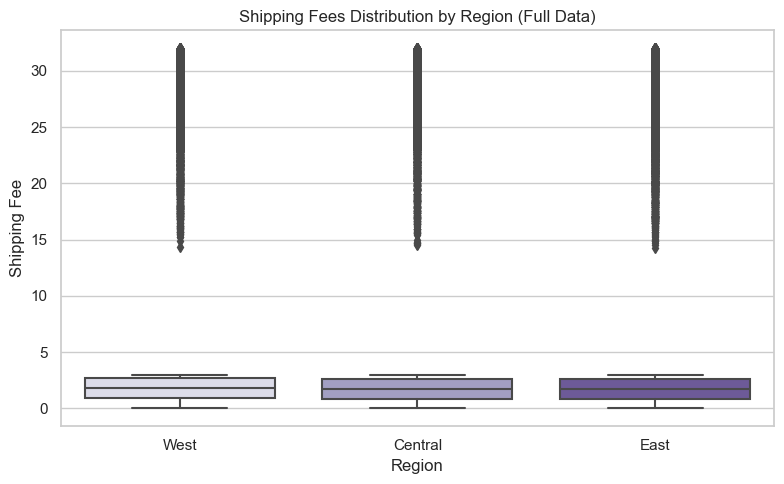

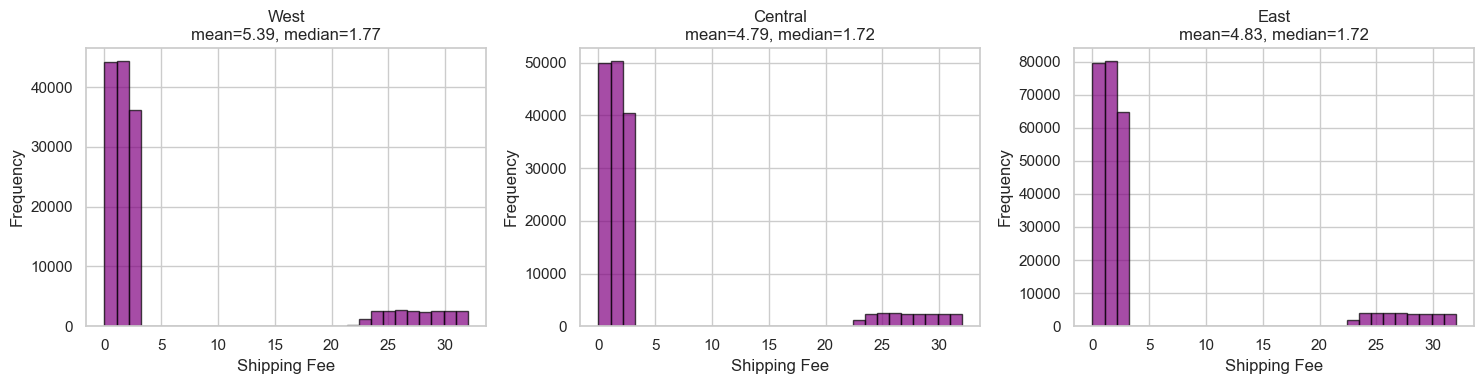

In [17]:
# Merge shipments với geography để lấy region
ship_full = shipments.copy()
ship_full = ship_full.merge(
    orders[['order_id', 'zip']], 
    on='order_id', 
    how='left'
)
ship_full = ship_full.merge(
    geography[['zip', 'region']],
    on='zip',
    how='left'
)

# 1.1) Shipping fee stats by region
region_ship_stats = (
    ship_full.groupby('region')
    .agg({
        'shipping_fee': ['count', 'mean', 'median', lambda x: x.quantile(0.90)]
    })
    .round(2)
)
region_ship_stats.columns = ['num_orders', 'mean_fee', 'median_fee', 'p90_fee']
region_ship_stats = region_ship_stats.sort_values('mean_fee', ascending=False)

print("=" * 60)
print("SHIPPING FEES BY REGION (Full Data)")
print("=" * 60)
display(region_ship_stats)

# Phần trăm chênh lệch
print("\nPercentage difference from baseline (Central):")
central_mean = region_ship_stats.loc['Central', 'mean_fee']
for region in region_ship_stats.index:
    diff_pct = ((region_ship_stats.loc[region, 'mean_fee'] - central_mean) / central_mean * 100)
    print(f"{region}: {diff_pct:+.1f}%")

# 1.2) Box plot shipping fee by region
plt.figure(figsize=(8, 5))
sns.boxplot(data=ship_full, x='region', y='shipping_fee', order=['West', 'Central', 'East'], palette='Purples')
plt.title('Shipping Fees Distribution by Region (Full Data)')
plt.ylabel('Shipping Fee')
plt.xlabel('Region')
plt.tight_layout()
plt.show()

# 1.3) Distribution histograms
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, region in enumerate(['West', 'Central', 'East']):
    data = ship_full[ship_full['region'] == region]['shipping_fee']
    axes[idx].hist(data, bins=30, alpha=0.7, edgecolor='black', color='purple')
    axes[idx].set_title(f'{region}\nmean={data.mean():.2f}, median={data.median():.2f}')
    axes[idx].set_xlabel('Shipping Fee')
    axes[idx].set_ylabel('Frequency')
plt.tight_layout()
plt.show()


d:\Code\DS_Code\revenue_forecast_ecommerce\notebooks\..\src\data_loader.py:40: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(PROCESSED / subfolder / filename)



REVENUE PER CUSTOMER BY REGION


,num_customers,mean_revenue_per_cust,median_revenue_per_cust,std
region,,,,
West,14741,248980.88,130492.62,297664.11
East,44721,163036.40,93253.08,194166.13
Central,30784,153309.88,75177.68,198809.45



Percentage difference from baseline (Central):
West: +62.4%
East: +6.3%
Central: +0.0%


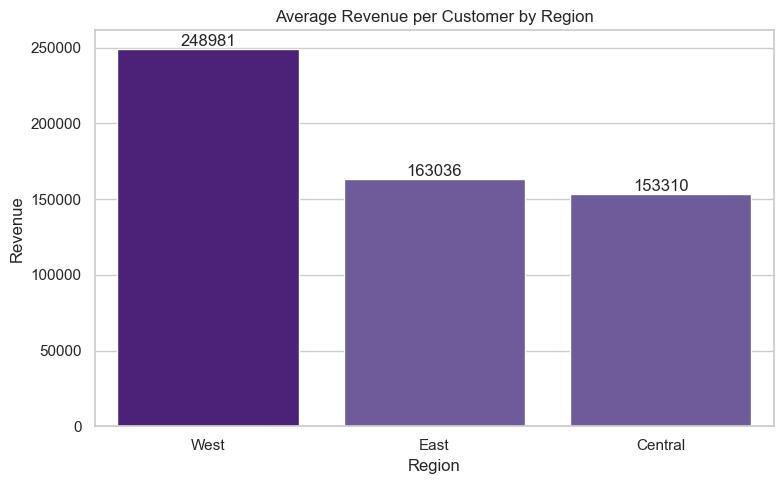

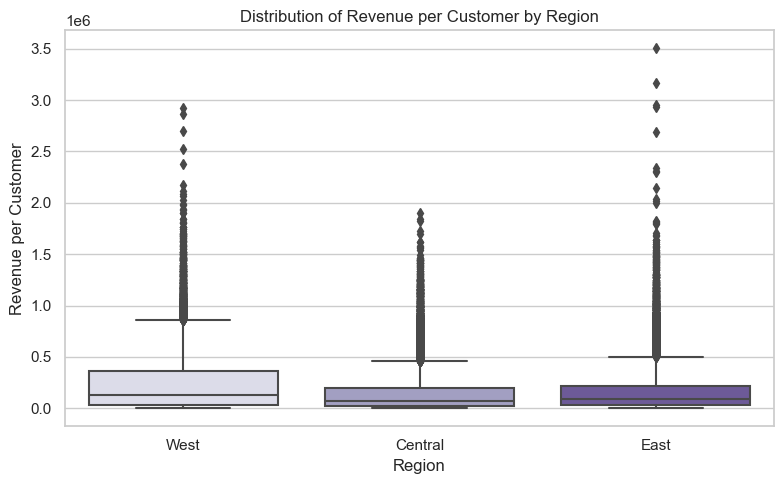

In [ ]:
# Load data
sales = load_processed('sales_clean.csv')
order_items = load_processed('order_items_clean.csv')

# Merge để tính revenue per order
order_revenue = (
    order_items
    .merge(orders[['order_id', 'customer_id', 'zip']], on='order_id', how='left')
    .merge(geography[['zip', 'region']], on='zip', how='left')
)

# Tính revenue per order (revenue = quantity * unit_price - discount)
order_revenue['revenue'] = (
    order_revenue['quantity'] * order_revenue['unit_price'] - 
    order_revenue['discount_amount'].fillna(0)
)

# Tính total revenue per customer
customer_region_revenue = (
    order_revenue
    .groupby(['customer_id', 'region'], as_index=False)
    .agg({
        'revenue': 'sum',
        'order_id': 'nunique'  # number of orders per customer
    })
    .rename(columns={'order_id': 'num_orders'})
)

# Revenue per customer by region
revenue_per_customer = customer_region_revenue.groupby('region')['revenue'].agg(['count', 'mean', 'median', 'std'])
revenue_per_customer.columns = ['num_customers', 'mean_revenue_per_cust', 'median_revenue_per_cust', 'std']
revenue_per_customer = revenue_per_customer.sort_values('mean_revenue_per_cust', ascending=False)

print("\n" + "=" * 60)
print("REVENUE PER CUSTOMER BY REGION")
print("=" * 60)
display(revenue_per_customer.round(2))

print("\nPercentage difference from baseline (Central):")
central_rev = revenue_per_customer.loc['Central', 'mean_revenue_per_cust']
for region in revenue_per_customer.index:
    diff_pct = ((revenue_per_customer.loc[region, 'mean_revenue_per_cust'] - central_rev) / central_rev * 100)
    print(f"{region}: {diff_pct:+.1f}%")

# 2.1) Bar plot - Mean revenue per customer
plt.figure(figsize=(8, 5))
colors = ['#4a1486' if x == 'West' else '#6a51a3' for x in revenue_per_customer.index]
sns.barplot(x=revenue_per_customer.index, y=revenue_per_customer['mean_revenue_per_cust'], palette=colors)
plt.title('Average Revenue per Customer by Region')
plt.ylabel('Revenue')
plt.xlabel('Region')
for i, v in enumerate(revenue_per_customer['mean_revenue_per_cust']):
    plt.text(i, v + 100, f'{v:.0f}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

# 2.2) Box plot distribution of revenue per customer
plt.figure(figsize=(8, 5))
sns.boxplot(data=customer_region_revenue, x='region', y='revenue', order=['West', 'Central', 'East'], palette='Purples')
plt.title('Distribution of Revenue per Customer by Region')
plt.ylabel('Revenue per Customer')
plt.xlabel('Region')
plt.tight_layout()
save_business('revenue_per_customer_by_region')
plt.show()



REPEAT PURCHASE FREQUENCY BY REGION


,region,num_customers,mean_orders_per_cust,median_orders_per_cust,total_orders,repeat_purchase_rate_pct
2,West,14741,11.37,6.0,167642,78.69
1,East,44721,6.59,4.0,294612,77.58
0,Central,30784,6.00,3.0,184691,70.14



Percentage difference from baseline (Central):
Central: +0.0%
East: +10.6%
West: +12.2%


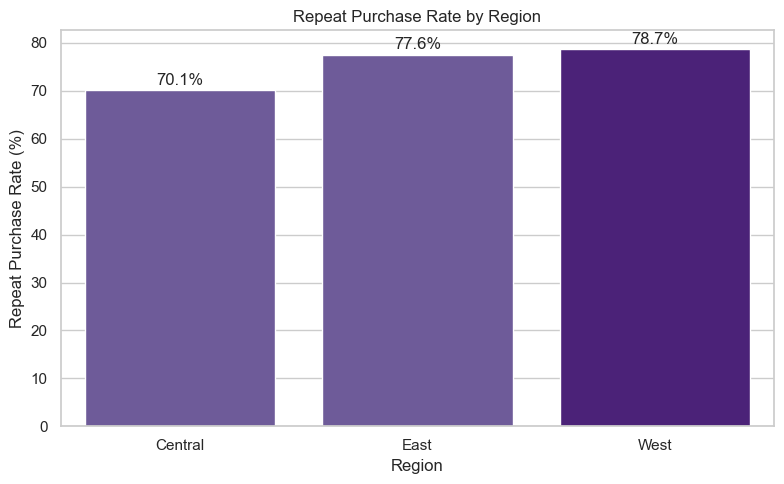

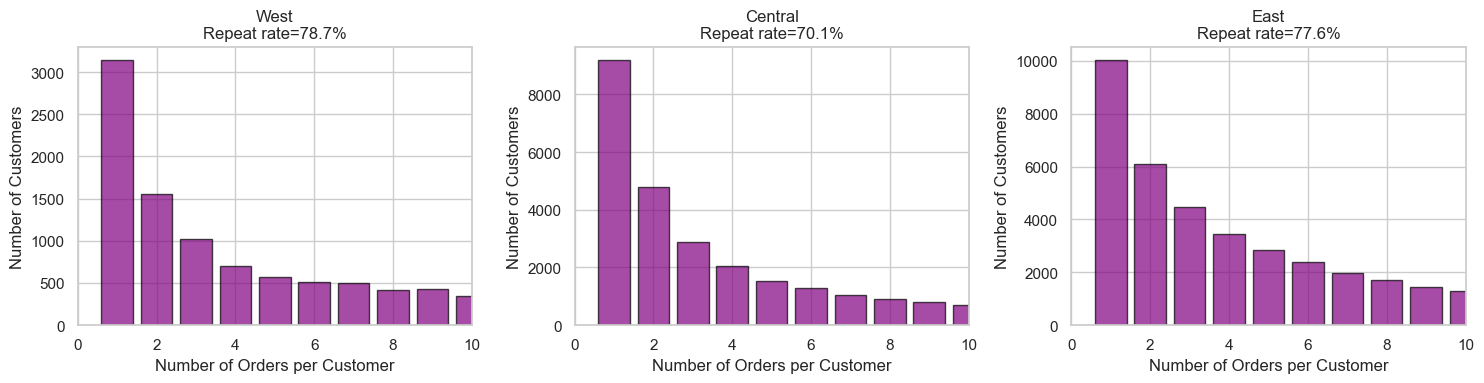

In [ ]:
customer_order_count = (
    orders
    .merge(geography[['zip', 'region']], on='zip', how='left')
    .groupby(['customer_id', 'region'], as_index=False)
    .size()
    .rename(columns={'size': 'num_orders'})
)

# Phân loại: One-time customer vs Repeat customer
customer_order_count['customer_type'] = customer_order_count['num_orders'].apply(
    lambda x: 'One-time' if x == 1 else 'Repeat'
)

# Repeat purchase frequency by region
repeat_rate = (
    customer_order_count
    .groupby('region')
    .agg({
        'customer_type': lambda x: (x == 'Repeat').sum() / len(x) * 100
    })
    .rename(columns={'customer_type': 'repeat_purchase_rate_pct'})
)

# Overall stats
customer_orders_by_region = (
    customer_order_count
    .groupby('region', as_index=False)
    .agg({
        'customer_id': 'count',  # total customers
        'num_orders': ['mean', 'median', 'sum']  # avg orders, median orders, total orders
    })
)
customer_orders_by_region.columns = ['region', 'num_customers', 'mean_orders_per_cust', 'median_orders_per_cust', 'total_orders']
customer_orders_by_region = customer_orders_by_region.merge(repeat_rate.reset_index(), on='region')
customer_orders_by_region = customer_orders_by_region.sort_values('repeat_purchase_rate_pct', ascending=False)

print("\n" + "=" * 60)
print("REPEAT PURCHASE FREQUENCY BY REGION")
print("=" * 60)
display(customer_orders_by_region.round(2))

# Phần trăm chênh lệch
print("\nPercentage difference from baseline (Central):")
central_repeat = repeat_rate.loc['Central', 'repeat_purchase_rate_pct']
for region in repeat_rate.index:
    diff_pct = ((repeat_rate.loc[region, 'repeat_purchase_rate_pct'] - central_repeat) / central_repeat * 100)
    print(f"{region}: {diff_pct:+.1f}%")

# 3.1) Repeat purchase rate by region
plt.figure(figsize=(8, 5))
colors = ['#4a1486' if x == 'West' else '#6a51a3' for x in repeat_rate.index]
sns.barplot(x=repeat_rate.index, y=repeat_rate['repeat_purchase_rate_pct'], palette=colors)
plt.title('Repeat Purchase Rate by Region')
plt.ylabel('Repeat Purchase Rate (%)')
plt.xlabel('Region')
for i, v in enumerate(repeat_rate['repeat_purchase_rate_pct']):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center', va='bottom')
plt.tight_layout()
save_business('repeat_purchase_rate_by_region')
plt.show()

# 3.2) Distribution of purchase frequency
purchase_freq = customer_order_count['num_orders'].value_counts().sort_index()
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, region in enumerate(['West', 'Central', 'East']):
    data = customer_order_count[customer_order_count['region'] == region]['num_orders']
    freq_dist = data.value_counts().sort_index()
    axes[idx].bar(freq_dist.index, freq_dist.values, alpha=0.7, edgecolor='black', color='purple')
    axes[idx].set_title(f'{region}\nRepeat rate={repeat_rate.loc[region, "repeat_purchase_rate_pct"]:.1f}%')
    axes[idx].set_xlabel('Number of Orders per Customer')
    axes[idx].set_ylabel('Number of Customers')
    axes[idx].set_xlim(0, 10)
plt.tight_layout()
plt.show()



AVERAGE ORDER VALUE (AOV) ANALYSIS BY REGION


,total_revenue,total_items,revenue_per_item,num_orders,aov_per_order
region,,,,,
Central,4.719491e+09,201342,23440.17,184691,25553.44
East,7.291151e+09,321293,22693.15,294612,24748.32
West,3.670227e+09,192034,19112.38,167642,21893.24



Percentage difference from baseline (Central):
Central AOV: +0.0%
East AOV: -3.2%
West AOV: -14.3%


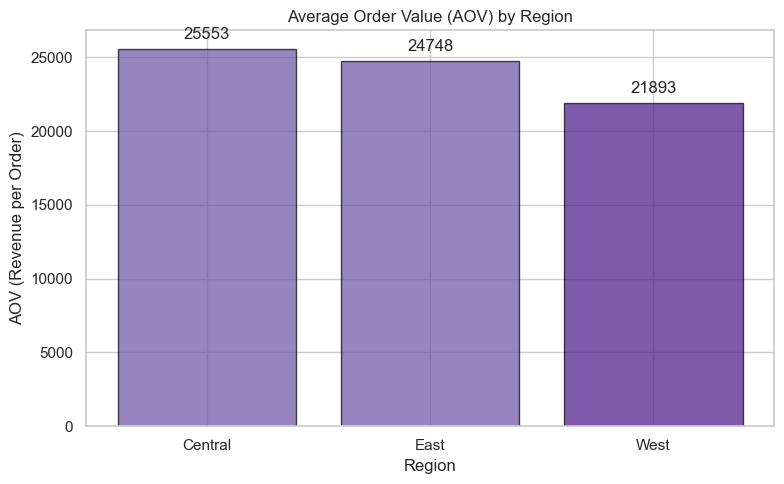

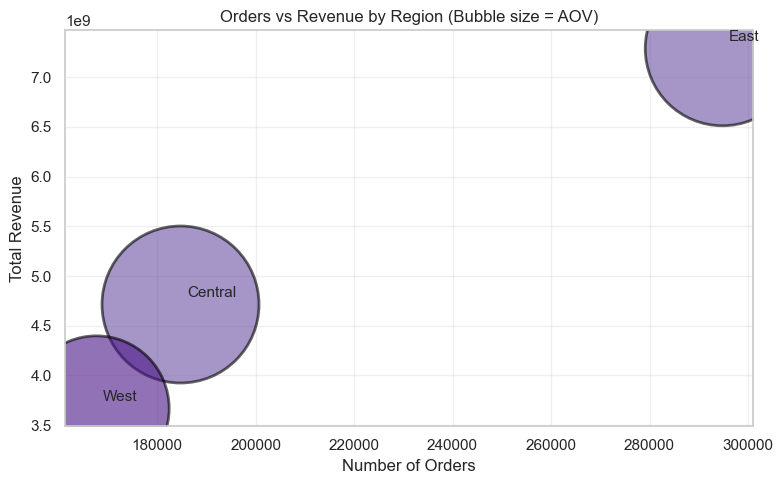

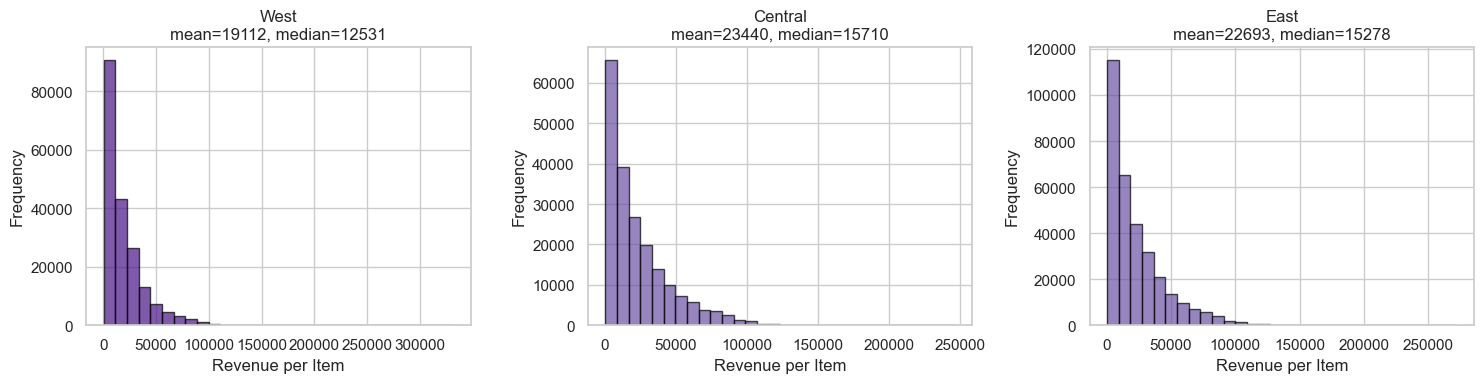

In [20]:
# Prepare order_revenue dataset with region information
order_revenue = (
    order_items
    .merge(orders[['order_id', 'zip']], on='order_id', how='left')
    .merge(geography[['zip', 'region']], on='zip', how='left')
)
order_revenue['revenue'] = (
    order_revenue['quantity'] * order_revenue['unit_price'] - 
    order_revenue['discount_amount'].fillna(0)
)

# Tính AOV = Total Revenue / Number of Orders by region

aov_by_region = (
    order_revenue
    .groupby('region')
    .agg({
        'revenue': ['sum', 'count', 'mean'],
        'order_id': 'nunique'
    })
)
aov_by_region.columns = ['total_revenue', 'total_items', 'revenue_per_item', 'num_orders']
aov_by_region['aov_per_order'] = aov_by_region['total_revenue'] / aov_by_region['num_orders']
aov_by_region = aov_by_region.sort_values('aov_per_order', ascending=False)

print("\n" + "=" * 60)
print("AVERAGE ORDER VALUE (AOV) ANALYSIS BY REGION")
print("=" * 60)
display(aov_by_region.round(2))

# Percentage difference
print("\nPercentage difference from baseline (Central):")
central_aov = aov_by_region.loc['Central', 'aov_per_order']
for region in aov_by_region.index:
    diff_pct = ((aov_by_region.loc[region, 'aov_per_order'] - central_aov) / central_aov * 100)
    print(f"{region} AOV: {diff_pct:+.1f}%")

# 6.1.1) AOV by Region - Bar Chart
plt.figure(figsize=(8, 5))
colors = ['#4a1486' if x == 'West' else '#6a51a3' for x in aov_by_region.index]
bars = plt.bar(aov_by_region.index, aov_by_region['aov_per_order'], color=colors, alpha=0.7, edgecolor='black')
plt.title('Average Order Value (AOV) by Region')
plt.ylabel('AOV (Revenue per Order)')
plt.xlabel('Region')
for i, v in enumerate(aov_by_region['aov_per_order']):
    plt.text(i, v + 500, f'{v:.0f}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

# 6.1.2) Number of Orders vs Total Revenue - Bubble Chart
fig, ax = plt.subplots(figsize=(8, 5))
for region in aov_by_region.index:
    num_orders = aov_by_region.loc[region, 'num_orders']
    total_rev = aov_by_region.loc[region, 'total_revenue']
    aov = aov_by_region.loc[region, 'aov_per_order']
    color = '#4a1486' if region == 'West' else '#6a51a3'
    # bubble size proportional to AOV
    ax.scatter(num_orders, total_rev, s=aov/2, alpha=0.6, c=color, edgecolors='black', linewidth=2)
    ax.annotate(region, (num_orders, total_rev), xytext=(5, 5), textcoords='offset points', fontsize=11)

ax.set_xlabel('Number of Orders')
ax.set_ylabel('Total Revenue')
ax.set_title('Orders vs Revenue by Region (Bubble size = AOV)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 6.1.3) Order Value Distribution by Region
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, region in enumerate(['West', 'Central', 'East']):
    data = order_revenue[order_revenue['region'] == region]['revenue']
    axes[idx].hist(data, bins=30, alpha=0.7, edgecolor='black', color=['#4a1486' if region == 'West' else '#6a51a3'][0])
    axes[idx].set_title(f'{region}\nmean={data.mean():.0f}, median={data.median():.0f}')
    axes[idx].set_xlabel('Revenue per Item')
    axes[idx].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

| Metric | West | East | Central | Kết luận |
|----------|----------:|----------:|----------:|----------|
| mean_shipping_fee | 5.39 | 4.83 | 4.79 | West có phí vận chuyển cao nhất |
| num_cities | 16 | 14 | 12 | West sở hữu độ phủ lớn nhất |
| num_customers | 14,741 | 44,721 | 30,784 | West có số lượng khách hàng thấp nhất |
| total_orders | 167,642 | 294,612 | 184,691 | West có số đơn hàng thấp nhất |
| AOV | 21.89 | 24.75 | 25.55 | AOV của West thấp nhất |
| total_revenue (B) | 3.67 | 7.29 | 4.72 | Doanh thu của West thấp nhất |
| revenue_per_customer | 248,981 | 163,036 | 153,310 | West có doanh thu trên mỗi khách hàng cao nhất |
| repeat_purchase_rate (%) | 78.69 | 77.58 | 70.14 | West có tỷ lệ mua lại cao nhất |
| mean_orders_per_customer | 11.37 | 6.59 | 6.00 | Tần suất mua hàng cao vượt trội |

Từ bảng trên, có thể thấy yếu tố logistics chưa phải là nguyên nhân chính giải thích sự khác biệt về hiệu quả kinh doanh giữa các khu vực. Mặc dù **West** có mức phí vận chuyển trung bình cao nhất (**5.39**), khu vực này vẫn ghi nhận **doanh thu trên mỗi khách hàng cao nhất (248,981)**, **tỷ lệ mua lại cao nhất (78.69%)** và **số đơn hàng trung bình trên mỗi khách hàng lớn nhất (11.37 đơn)**.

Đáng chú ý, West cũng là khu vực có **số lượng khách hàng thấp nhất (14,741 khách)**, **số đơn hàng thấp nhất (167,642 đơn)** và **tổng doanh thu thấp nhất (3.67 tỷ đồng)**, dù sở hữu độ phủ lớn nhất với **16 thành phố**. Điều này cho thấy tăng trưởng tại West không đến từ quy mô khách hàng mà chủ yếu đến từ mức độ gắn bó của khách hàng hiện hữu.

Bên cạnh đó, **AOV** của West chỉ đạt **21.89 nghìn đồng**, thấp hơn East (**24.75 nghìn đồng**) và Central (**25.55 nghìn đồng**). Do đó, doanh thu trên mỗi khách hàng cao tại West không xuất phát từ giá trị đơn hàng lớn hơn mà chủ yếu đến từ **tần suất mua hàng cao hơn đáng kể**.

Tuy nhiên, việc West có độ phủ lớn nhất nhưng vẫn sở hữu quy mô khách hàng và doanh thu thấp nhất cho thấy doanh nghiệp có thể chưa khai thác hết tiềm năng thị trường tại khu vực này. Đây là cơ hội để mở rộng tệp khách hàng mới đồng thời tận dụng mức độ trung thành cao của khách hàng hiện hữu nhằm thúc đẩy tăng trưởng trong tương lai.

## 4. Phân tích nguyên nhân tiềm ẩn

### 1. Doanh thu xuất hiện điểm gãy từ năm 2019 dù traffic vẫn tăng
**Nguyên nhân tiềm ẩn:** Doanh nghiệp phụ thuộc lớn vào **Streetwear** – danh mục đóng góp doanh thu chủ lực. Trong khi traffic tiếp tục tăng, hiệu quả chuyển đổi của danh mục này suy giảm theo thời gian, khiến lượng truy cập không còn được chuyển hóa thành đơn hàng và doanh thu như giai đoạn trước.

### 2. Biên lợi nhuận biến động mạnh và không đồng nhất với doanh thu
**Nguyên nhân tiềm ẩn:** Các chương trình **Promotion** được triển khai với cường độ cao nhằm duy trì tăng trưởng doanh thu. Chi phí giảm giá tăng nhanh hơn tốc độ tăng doanh thu, làm biên lợi nhuận suy giảm và biến động qua các năm.

### 3. Traffic tăng nhưng doanh thu giảm
**Nguyên nhân tiềm ẩn:** Vấn đề nằm ở **conversion** hơn là khả năng thu hút khách hàng. Mặc dù lượng truy cập tăng, Conversion Rate của các danh mục chủ lực như **Streetwear** và **Outdoor** lại có xu hướng giảm, làm hiệu quả khai thác traffic suy yếu.

### 4. Orders giảm nhưng AOV tăng
**Nguyên nhân tiềm ẩn:** Doanh nghiệp có xu hướng tăng giá bán hoặc tập trung vào các sản phẩm giá trị cao hơn. Điều này giúp **AOV tăng**, nhưng đồng thời làm giảm số lượng đơn hàng và hạn chế tăng trưởng về sản lượng bán.

### 5. "Wrong Size" là nguyên nhân trả hàng phổ biến nhất
**Nguyên nhân tiềm ẩn:** Hệ thống sản phẩm đang tồn tại tình trạng **"khóa màu theo size"**, khiến khách hàng khó tìm được đúng màu sắc và kích thước mong muốn. Điều này làm giảm trải nghiệm mua sắm, tăng tỷ lệ trả hàng và khiến một phần doanh thu không được chuyển hóa thành doanh thu thực nhận.

### 6. Tồn kho chưa được phân bổ tối ưu theo nhu cầu thị trường
**Nguyên nhân tiềm ẩn:** Phân tích cho thấy **GenZ** có tỷ lệ hết hàng cao nhất dù sở hữu ít SKU nhất, trong khi một số danh mục khác vẫn duy trì mức tồn kho tương đối ổn định. Điều này cho thấy nguồn lực tồn kho có thể chưa được phân bổ phù hợp với nhu cầu thực tế, làm mất cơ hội doanh thu ở các danh mục tăng trưởng cao.

### 7. Tiềm năng thị trường chưa được khai thác đồng đều giữa các khu vực
**Nguyên nhân tiềm ẩn:** Khu vực **West** có tỷ lệ mua lại, doanh thu trên mỗi khách hàng và số đơn hàng trên mỗi khách hàng cao nhất, nhưng lại sở hữu quy mô khách hàng và tổng doanh thu thấp nhất. Điều này cho thấy doanh nghiệp đang giữ chân khách hàng tốt nhưng chưa mở rộng được tệp khách hàng mới, dẫn đến việc chưa khai thác hết tiềm năng của thị trường.